In [ ]:
# CP 與 CIR 模型訓練
import os
import sys
import subprocess

# ===== 基本路徑設定（依你目前環境）=====
PROJECT_ROOT = "/home/ester/valid_description/text-conditioned-outfit-recommendation"
DATA_ROOT = "/home/ester/valid_description"
FASHIONCLIP_DIR = os.path.join(DATA_ROOT, "fashionclip_data")

# 切到專案根目錄（避免 notebook 在別的地方執行）
os.chdir(PROJECT_ROOT)

# ===== 基本設定 =====
seeds = [1,2,3,4,5]
exp_root = "./experiments_none_only"  # 相對於 PROJECT_ROOT

# 你前面產生的 subset ids（txt，一行一個 id）
subset_ids_path = os.path.join(DATA_ROOT, "no_missing_none_ids.txt")

# 5 種文字特徵版本（train_*.py 目前吃的是檔名，不是完整路徑）
text_variants = {
    "outfitUrlTitle": "encoded_outfitUrlTitle_en_fashionClip.pkl",
    "NewoutfitUrlTitle": "encoded_NewoutfitUrlTitle_en_fashionClip.pkl",
    "no_weather": "encoded_no_weather_outfitUrlTitle_en_fashionClip.pkl",
    "no_occasion": "encoded_no_occasion_outfitUrlTitle_en_fashionClip.pkl",
    "no_style": "encoded_no_style_outfitUrlTitle_en_fashionClip.pkl",
}

def run_if_needed(cmd, ckpt_path, label):
    """如果 ckpt 已存在就略過，否則執行訓練。"""
    if os.path.exists(ckpt_path):
        print(f"[SKIP] {label}: 已存在 {ckpt_path}，略過訓練。")
        return
    print(f"[RUN ] {label}: 開始訓練，將產生 {ckpt_path}")
    print("      CMD =", " ".join(cmd))
    subprocess.run(cmd, check=True)

# ===== 執行前檢查 =====
print("目前工作目錄:", os.getcwd())
print("Python:", sys.executable)

if not os.path.exists(subset_ids_path):
    raise FileNotFoundError(f"找不到 subset ids 檔案：{subset_ids_path}")

print(f"✓ subset_ids_path exists: {subset_ids_path}")

# 檢查 pkl 檔是否真的在你說的位置
for variant, feat_name in text_variants.items():
    feat_full_path = os.path.join(FASHIONCLIP_DIR, feat_name)
    if not os.path.exists(feat_full_path):
        raise FileNotFoundError(f"找不到文字特徵檔：{feat_full_path}")
    print(f"✓ {variant:16s} -> {feat_full_path}")

# ===== 主流程 =====
# 總數：5 種 variant × 2 任務 × 5 seeds = 50 次（有些會 skip）
for seed in seeds:
    print("\n========================")
    print(f"===== seed = {seed} =====")
    print("========================\n")

    for variant, outfit_feat_name in text_variants.items():
        subset_tag = "subset" if subset_ids_path else "all"

        # ---------- 1) CP ----------
        cp_exp_name = f"cp_{variant}_{subset_tag}_seed{seed}"
        cp_ckpt = os.path.join(exp_root, cp_exp_name, "ckpt.pt")

        cp_cmd = [
            sys.executable, "train_cp.py",
            f"--seed={seed}",
            f"--subset_ids_path={subset_ids_path}",
            f"--variant={variant}",
            f"--outfit_feat_name={outfit_feat_name}",
            f"--exp_root={exp_root}",
        ]

        run_if_needed(
            cp_cmd,
            cp_ckpt,
            label=f"CP ({variant}, seed={seed})"
        )

        # ---------- 2) CIR ----------
        cir_exp_name = f"cir_{variant}_{subset_tag}_seed{seed}"
        cir_ckpt = os.path.join(exp_root, cir_exp_name, "ckpt.pt")

        # 明確指定對應 CP checkpoint（避免推導路徑不一致）
        cir_cmd = [
            sys.executable, "train_cir.py",
            f"--seed={seed}",
            f"--subset_ids_path={subset_ids_path}",
            f"--variant={variant}",
            f"--outfit_feat_name={outfit_feat_name}",
            f"--exp_root={exp_root}",
            f"--pretrained_cp_ckpt={cp_ckpt}",
        ]

        run_if_needed(
            cir_cmd,
            cir_ckpt,
            label=f"CIR ({variant}, seed={seed})"
        )

print("\n✅ 全部完成（train_cp.py / train_cir.py，5 種文字特徵，subset none ids）。")

In [11]:
# CP 與 CIR 模型測試(評估)
import os
import sys
import subprocess

# ===== 設定 =====
seeds = [4,5]

# 你訓練用的 exp_root（請和 train 一致）
exp_root = "./experiments_none_only"

# subset none ids（txt，一行一個 id）
subset_ids_path = "/home/ester/valid_description/no_missing_none_ids.txt"

# 5 種文字特徵
text_variants = {
    "outfitUrlTitle": "encoded_outfitUrlTitle_en_fashionClip.pkl",
    "NewoutfitUrlTitle": "encoded_NewoutfitUrlTitle_en_fashionClip.pkl",
    "no_weather": "encoded_no_weather_outfitUrlTitle_en_fashionClip.pkl",
    "no_occasion": "encoded_no_occasion_outfitUrlTitle_en_fashionClip.pkl",
    "no_style": "encoded_no_style_outfitUrlTitle_en_fashionClip.pkl",
}

# evaluate 程式會輸出的結果檔（新版）
results_cp = os.path.join(exp_root, "results_cp.csv")
results_cir = os.path.join(exp_root, "results_cir.csv")


def already_has_row(results_file, seed, variant, subset_tag="subset"):
    """
    判斷 results_file 裡是否已經有 (seed, variant, subset_tag) 的結果列。
    依照你新版 CSV 欄位：seed,variant,subset_tag,...
    """
    if not os.path.exists(results_file):
        return False

    target = f"{seed},{variant},{subset_tag},"
    with open(results_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith(target):
                return True
    return False


def run_eval_if_needed(cmd, results_file, seed, variant, label):
    subset_tag = "subset" if subset_ids_path else "all"

    if already_has_row(results_file, seed, variant, subset_tag=subset_tag):
        print(f"[SKIP] {label}: {results_file} 已有 seed={seed}, variant={variant}, subset={subset_tag} 的結果，略過評估。")
        return

    print(f"[RUN ] {label}: 開始評估")
    print("      CMD =", " ".join(cmd))

    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"

    # 用 python -u 避免 tqdm/print buffer（看起來不會卡）
    cmd2 = cmd.copy()
    cmd2.insert(1, "-u")  # sys.executable -u xxx.py ...

    subprocess.run(cmd2, check=True, env=env)


# ===== 前置檢查 =====
if subset_ids_path and (not os.path.exists(subset_ids_path)):
    raise FileNotFoundError(f"找不到 subset ids：{subset_ids_path}")

print("Python:", sys.executable)
print("exp_root:", exp_root)
print("subset_ids_path:", subset_ids_path)
print("results_cp:", results_cp)
print("results_cir:", results_cir)

# ===== 主流程 =====
for seed in seeds:
    print("\n========================")
    print(f"===== eval seed = {seed} =====")
    print("========================\n")

    for variant, outfit_feat_name in text_variants.items():
        # ---- CP ----
        run_eval_if_needed(
            [
                sys.executable, "evaluate_cp.py",
                f"--seed={seed}",
                f"--exp_root={exp_root}",
                f"--variant={variant}",
                f"--outfit_feat_name={outfit_feat_name}",
                f"--subset_ids_path={subset_ids_path}",
            ],
            results_cp,
            seed,
            variant,
            label=f"CP (variant={variant}, seed={seed})",
        )

        # ---- CIR ----
        run_eval_if_needed(
            [
                sys.executable, "evaluate_cir.py",
                f"--seed={seed}",
                f"--exp_root={exp_root}",
                f"--variant={variant}",
                f"--outfit_feat_name={outfit_feat_name}",
                f"--subset_ids_path={subset_ids_path}",
                "--run_tag=none_subset",
                # 若你要存 detail，再打開下一行
                # "--save_detail",
            ],
            results_cir,
            seed,
            variant,
            label=f"CIR (variant={variant}, seed={seed})",
        )

print("\n✅ 所有 seed × variant 的評估流程已完成（有的跑、有的略過）。")
print("請確認：")
print(" -", results_cp)
print(" -", results_cir)

Python: /home/ester/miniforge3/envs/minenv/bin/python
exp_root: ./experiments_none_only
subset_ids_path: /home/ester/valid_description/no_missing_none_ids.txt
results_cp: ./experiments_none_only/results_cp.csv
results_cir: ./experiments_none_only/results_cir.csv

===== eval seed = 4 =====

[SKIP] CP (variant=outfitUrlTitle, seed=4): ./experiments_none_only/results_cp.csv 已有 seed=4, variant=outfitUrlTitle, subset=subset 的結果，略過評估。
[SKIP] CIR (variant=outfitUrlTitle, seed=4): ./experiments_none_only/results_cir.csv 已有 seed=4, variant=outfitUrlTitle, subset=subset 的結果，略過評估。
[SKIP] CP (variant=NewoutfitUrlTitle, seed=4): ./experiments_none_only/results_cp.csv 已有 seed=4, variant=NewoutfitUrlTitle, subset=subset 的結果，略過評估。
[SKIP] CIR (variant=NewoutfitUrlTitle, seed=4): ./experiments_none_only/results_cir.csv 已有 seed=4, variant=NewoutfitUrlTitle, subset=subset 的結果，略過評估。
[SKIP] CP (variant=no_weather, seed=4): ./experiments_none_only/results_cp.csv 已有 seed=4, variant=no_weather, subset=subset 的

2026-03-11 21:44:21.149100: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 21:44:21.360247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773236661.436406  107861 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773236661.458513  107861 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773236661.635164  107861 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

[CP EVAL] seed=5, variant=outfitUrlTitle, subset_tag=subset, exp_dir=./experiments_none_only/cp_outfitUrlTitle_subset_seed5
always_save_checkpoint                  True                                    
batch_size                              50                                      
category_feat_path                      './encoded_category_distiluse-base-multilingual-cased-v2.pkl'
compile_model                           False                                   
datadir                                 'E:\\Datasets\\UIUC-polyvore'           
decay_lr                                True                                    
device                                  device(type='cuda', index=0)            
device_type                             'cuda'                                  
dropout                                 0.1                                     
dtype                                   'float16'                               
epochs                                  100  

compute FITB:   0%|          | 12/9930 [00:00<01:28, 112.19it/s]

AUC: 0.912


...

[CIR EVAL] seed=5, variant=no_style, subset_tag=subset, exp_dir=./experiments_none_only/cir_no_style_subset_seed5
always_save_checkpoint                  True                                    
batch_size                              50                                      
category_feat_path                      './encoded_category_distiluse-base-multilingual-cased-v2.pkl'
compile_model                           False                                   
datadir                                 'E:\\Datasets\\UIUC-polyvore'           
decay_lr                                True                                    
device                                  device(type='cuda', index=0)            
device_type                             'cuda'                                  
dropout                                 0.1                                     
dtype                                   'float16'                               
epochs                                  100            

compute recall@topk:   0%|          | 0/9930 [00:00<?, ?it/s]

[8/151] fine-grained categories are selected.


compute recall@topk: 100%|██████████| 9930/9930 [00:13<00:00, 759.11it/s]


Recall@top1: 0.9615%
Recall@top3: 2.7098%
Recall@top5: 4.2541%
Recall@top10: 7.2844%
Recall@top30: 15.4720%
Recall@top50: 21.0664%
[CIR EVAL] 結果已寫入 ./experiments_none_only/results_cir.csv

✅ 所有 seed × variant 的評估流程已完成（有的跑、有的略過）。
請確認：
 - ./experiments_none_only/results_cp.csv
 - ./experiments_none_only/results_cir.csv


CP  variants: ['NewoutfitUrlTitle', 'no_occasion', 'no_style', 'no_weather', 'outfitUrlTitle']
CIR variants: ['NewoutfitUrlTitle', 'no_occasion', 'no_style', 'no_weather', 'outfitUrlTitle']

=== Section A ===


,task,section,metric,baseline,target,n,paired_seeds,baseline_mean,baseline_std,target_mean,target_std,delta_mean,delta_std,p_ttest,p_wilcoxon,cohens_dz,p_ttest_holm,p_wilcoxon_holm,sig
0,CP,subset_validation,fitb_acc,outfitUrlTitle,NewoutfitUrlTitle,5,"[1, 2, 3, 4, 5]",0.610856,0.003484,0.622800,0.003383,0.011944,0.005802,0.010005,0.0625,2.058705,0.020010,0.3125,*
1,CP,subset_validation,auc,outfitUrlTitle,NewoutfitUrlTitle,5,"[1, 2, 3, 4, 5]",0.911163,0.001529,0.926451,0.001451,0.015288,0.001777,0.000043,0.0625,8.601431,0.000215,0.3125,***
2,CIR,subset_validation,recall_at_10,outfitUrlTitle,NewoutfitUrlTitle,5,"[1, 2, 3, 4, 5]",0.068590,0.004325,0.078147,0.002279,0.009557,0.006461,0.029722,0.0625,1.479189,0.029722,0.3125,*
3,CIR,subset_validation,recall_at_30,outfitUrlTitle,NewoutfitUrlTitle,5,"[1, 2, 3, 4, 5]",0.151690,0.007735,0.172028,0.003358,0.020338,0.007770,0.004252,0.0625,2.617336,0.012757,0.3125,*
4,CIR,subset_validation,recall_at_50,outfitUrlTitle,NewoutfitUrlTitle,5,"[1, 2, 3, 4, 5]",0.211072,0.004633,0.235140,0.004471,0.024068,0.005041,0.000436,0.0625,4.774487,0.001744,0.3125,**



=== Section B ===


,task,section,metric,baseline,target,n,paired_seeds,baseline_mean,baseline_std,target_mean,target_std,delta_mean,delta_std,p_ttest,p_wilcoxon,cohens_dz,p_ttest_holm,p_wilcoxon_holm,sig,factor
0,CP,factor_ablation,fitb_acc,NewoutfitUrlTitle,no_weather,5,"[1, 2, 3, 4, 5]",0.622800,0.003383,0.619114,0.005959,-0.003686,0.006620,0.281099,0.1875,-0.556768,1.000000,1.0000,n.s.,weather
1,CP,factor_ablation,auc,NewoutfitUrlTitle,no_weather,5,"[1, 2, 3, 4, 5]",0.926451,0.001451,0.924122,0.003393,-0.002329,0.004755,0.334914,0.3125,-0.489828,1.000000,1.0000,n.s.,weather
2,CIR,factor_ablation,recall_at_10,NewoutfitUrlTitle,no_weather,5,"[1, 2, 3, 4, 5]",0.078147,0.002279,0.075991,0.001326,-0.002156,0.001850,0.059637,0.0625,-1.165680,0.536729,0.9375,n.s.,weather
3,CIR,factor_ablation,recall_at_30,NewoutfitUrlTitle,no_weather,5,"[1, 2, 3, 4, 5]",0.172028,0.003358,0.168998,0.004716,-0.003030,0.003281,0.107817,0.1250,-0.923578,0.862536,1.0000,n.s.,weather
4,CIR,factor_ablation,recall_at_50,NewoutfitUrlTitle,no_weather,5,"[1, 2, 3, 4, 5]",0.235140,0.004471,0.232517,0.006774,-0.002622,0.004734,0.283218,0.3125,-0.553912,1.000000,1.0000,n.s.,weather
5,CP,factor_ablation,fitb_acc,NewoutfitUrlTitle,no_occasion,5,"[1, 2, 3, 4, 5]",0.622800,0.003383,0.619718,0.002422,-0.003082,0.005204,0.256097,0.3125,-0.592108,1.000000,1.0000,n.s.,occasion
6,CP,factor_ablation,auc,NewoutfitUrlTitle,no_occasion,5,"[1, 2, 3, 4, 5]",0.926451,0.001451,0.923580,0.001451,-0.002871,0.002270,0.047408,0.1250,-1.265029,0.474080,1.0000,n.s.,occasion
7,CIR,factor_ablation,recall_at_10,NewoutfitUrlTitle,no_occasion,5,"[1, 2, 3, 4, 5]",0.078147,0.002279,0.077389,0.000935,-0.000758,0.001827,0.406216,0.6250,-0.414741,1.000000,1.0000,n.s.,occasion
8,CIR,factor_ablation,recall_at_30,NewoutfitUrlTitle,no_occasion,5,"[1, 2, 3, 4, 5]",0.172028,0.003358,0.170629,0.003046,-0.001399,0.004908,0.558621,0.8125,-0.284978,1.000000,1.0000,n.s.,occasion
9,CIR,factor_ablation,recall_at_50,NewoutfitUrlTitle,no_occasion,5,"[1, 2, 3, 4, 5]",0.235140,0.004471,0.234732,0.001376,-0.000408,0.003358,0.799333,1.0000,-0.121487,1.000000,1.0000,n.s.,occasion


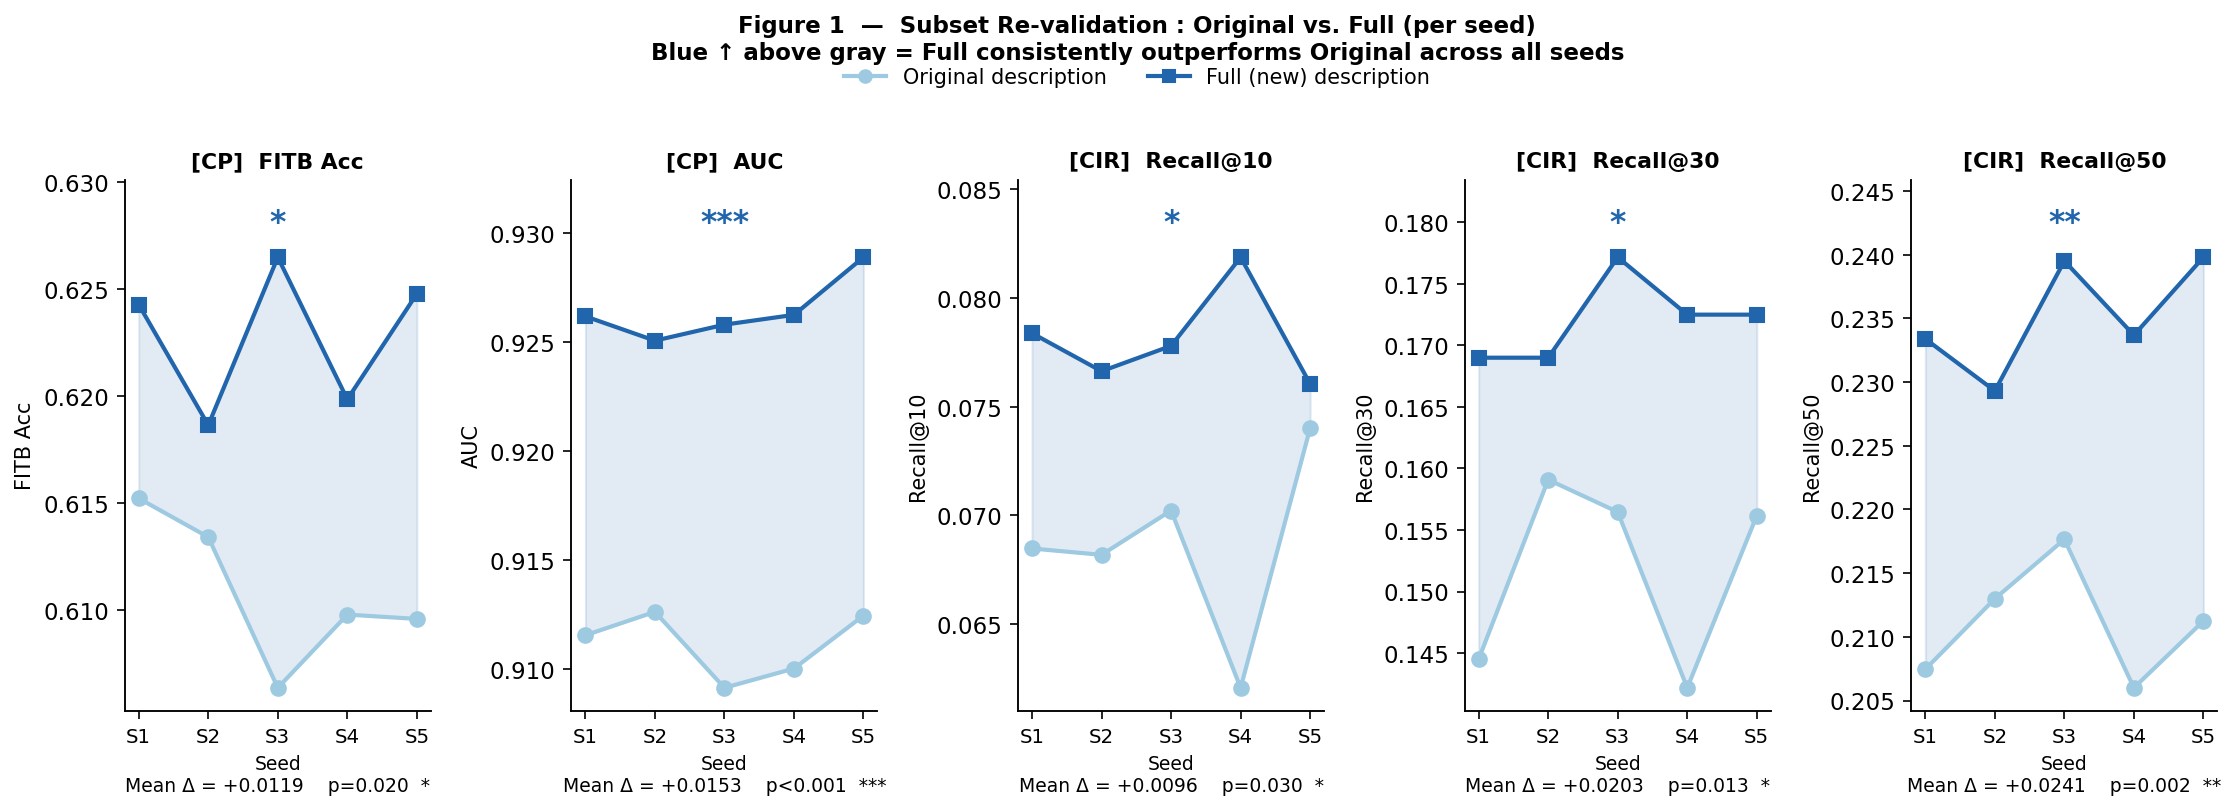

[已儲存] fig1_subset_validation.pdf / .png


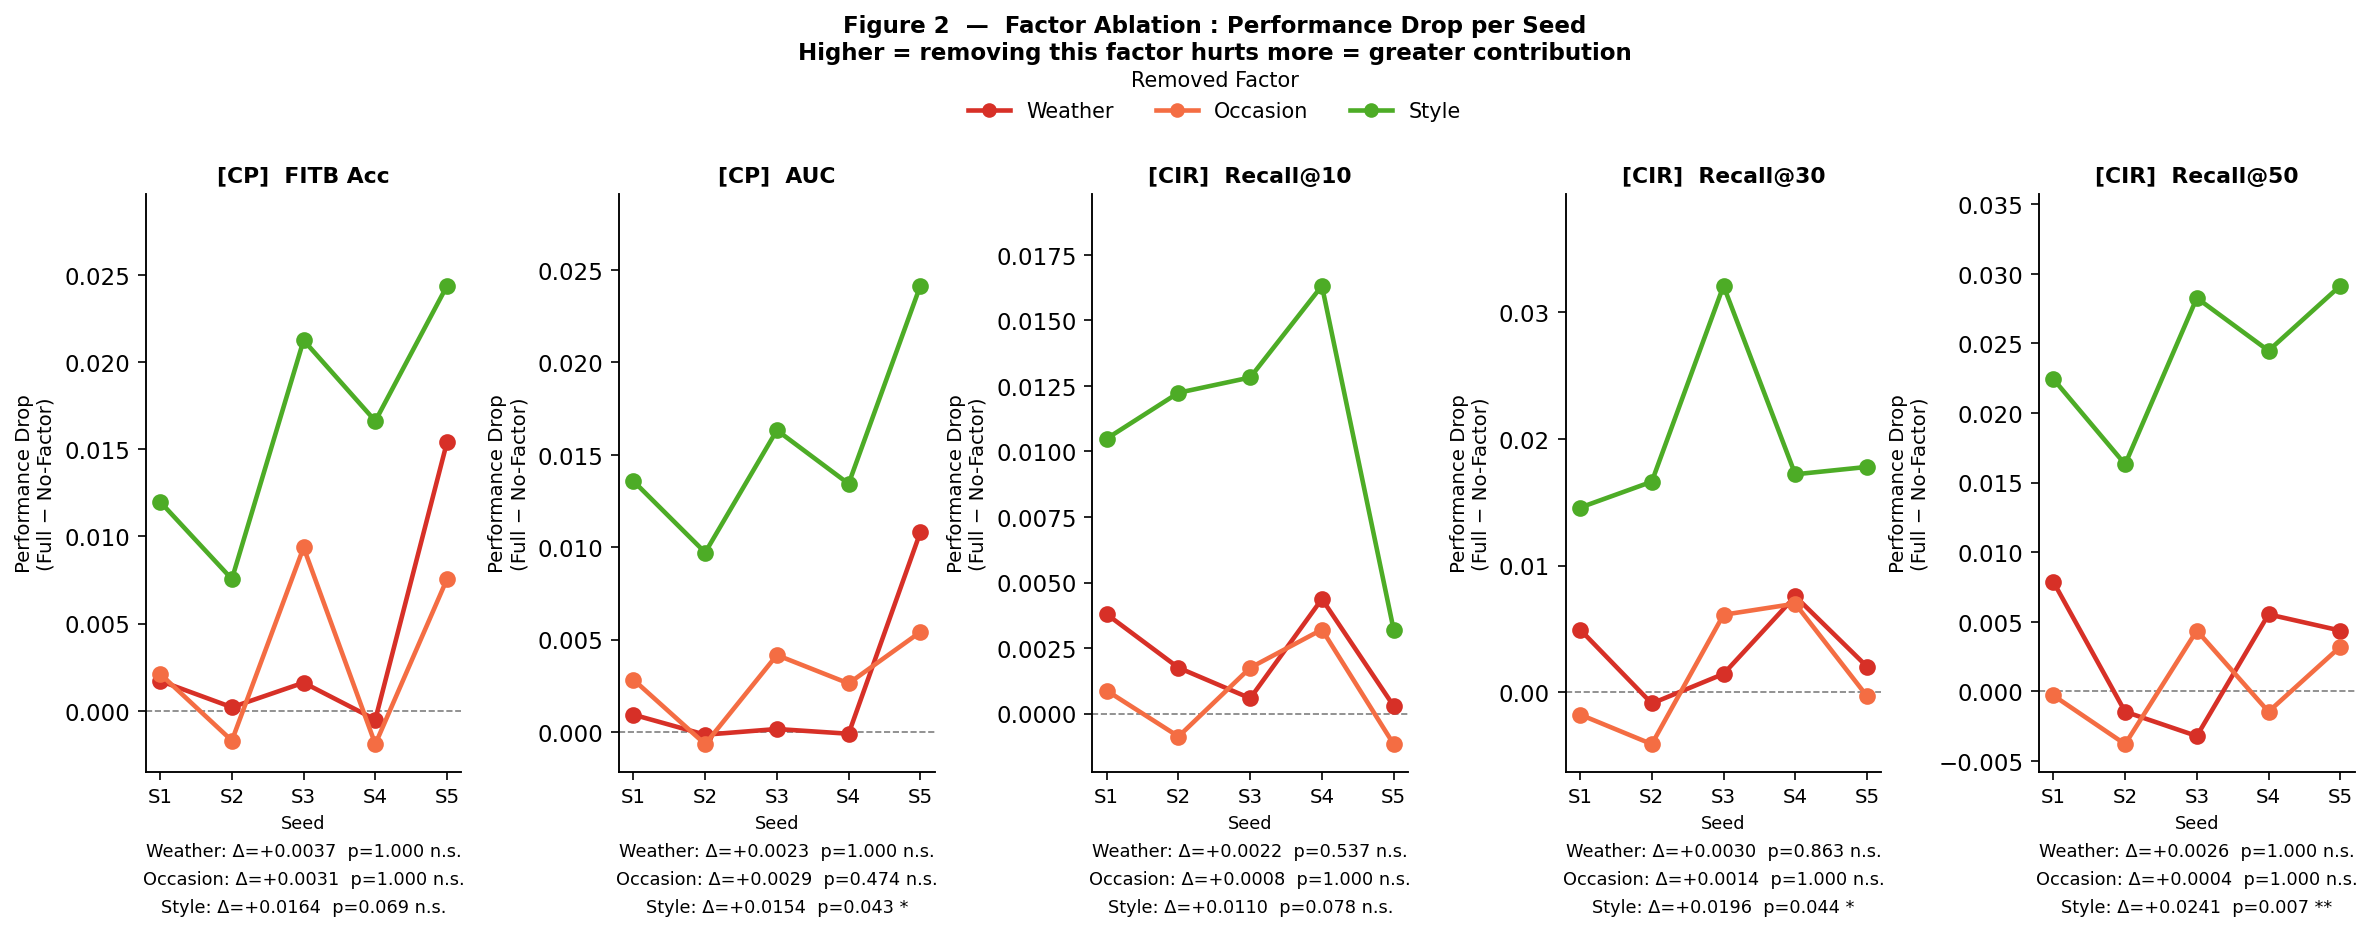

[已儲存] fig2_ablation_per_seed.pdf / .png


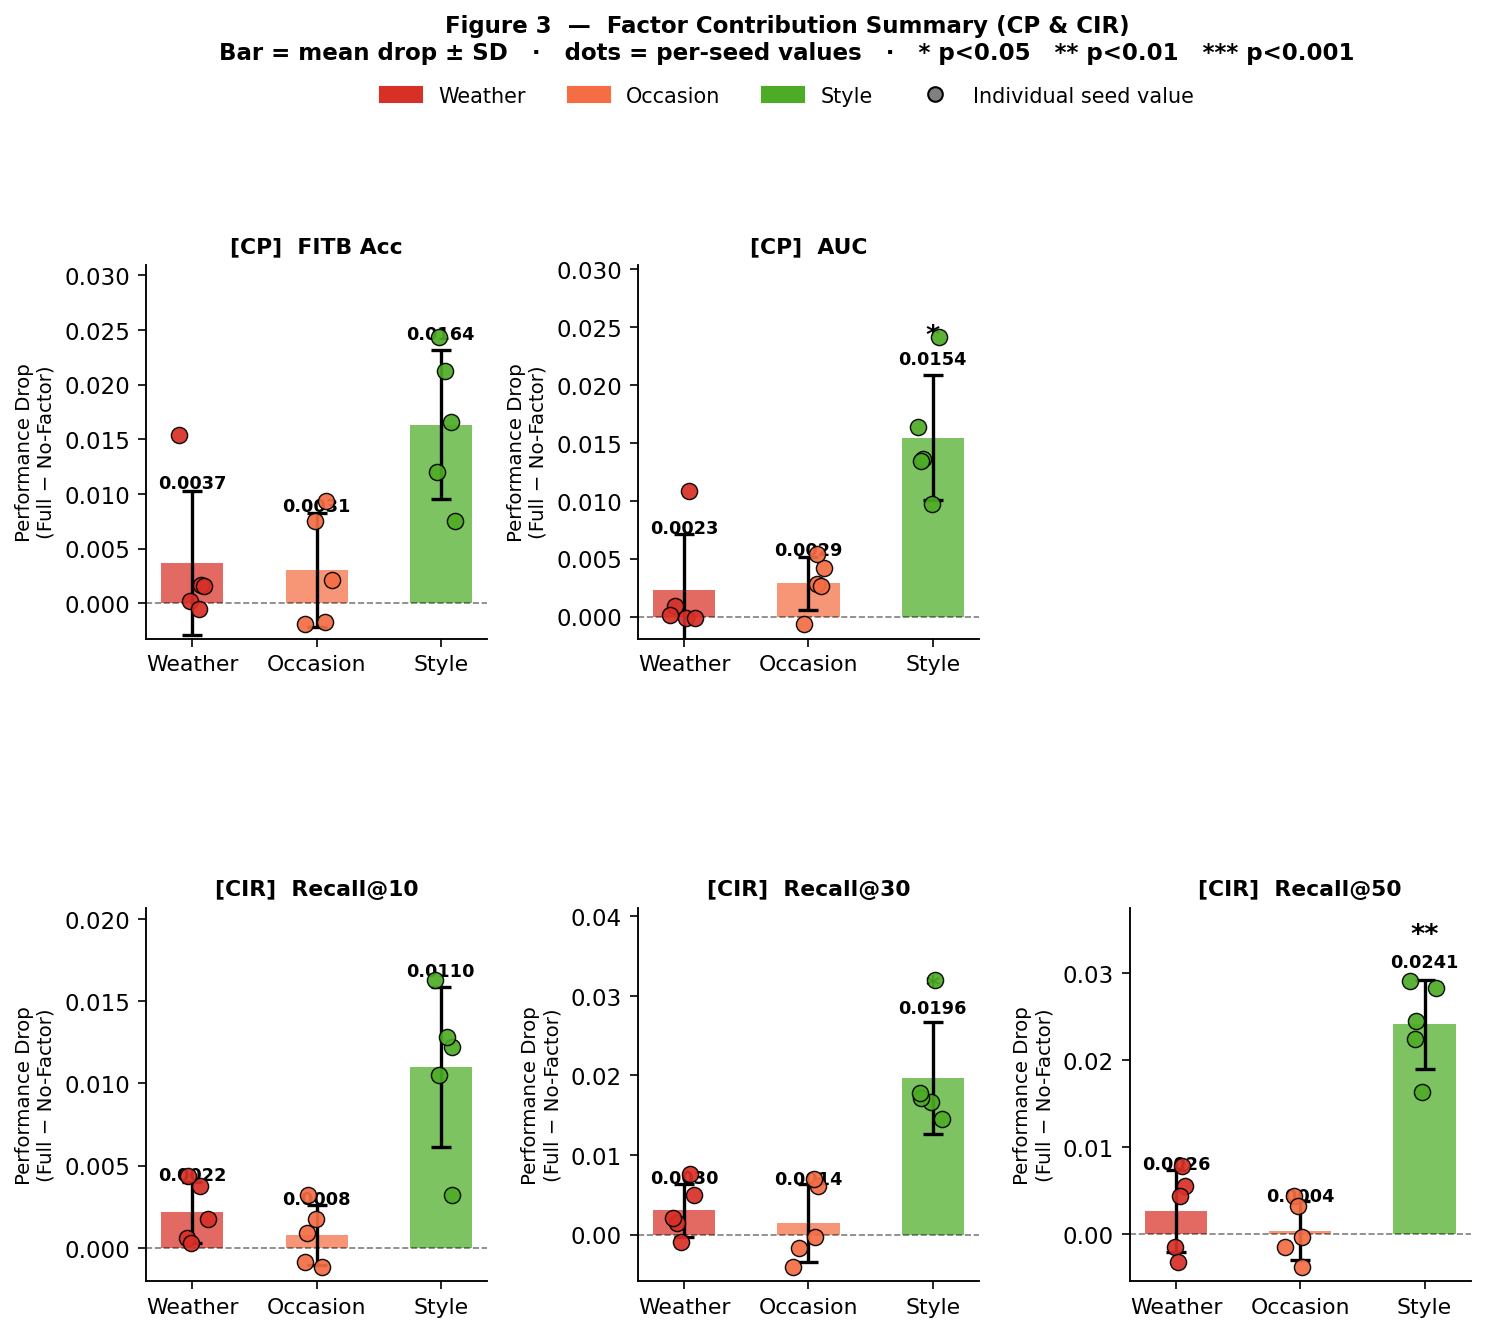

[已儲存] fig3_factor_bar_seeds.pdf / .png

✓ 所有表格已輸出至 ./analysis_outputs/
✓ 圖表 fig1–fig3 已儲存為 .pdf（論文投稿）與 .png（投影片）


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import ttest_rel, wilcoxon
from IPython.display import display

# =========================================
# 0) 基本設定
# =========================================
EXP_ROOT = "./experiments_none_only"
CP_CSV   = os.path.join(EXP_ROOT, "results_cp.csv")
CIR_CSV  = os.path.join(EXP_ROOT, "results_cir.csv")

SUBSET_TAG  = "subset"
CIR_RUN_TAG = "none_subset"

ORIGINAL = "outfitUrlTitle"
FULL     = "NewoutfitUrlTitle"
ABLATIONS = ["no_weather", "no_occasion", "no_style"]

CP_METRICS  = ["fitb_acc", "auc"]
CIR_METRICS = ["recall_at_10", "recall_at_30", "recall_at_50"]

OUTPUT_DIR = "./analysis_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 全域樣式 ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.linewidth":    0.9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

C_ORIG    = "#9ecae1"
C_FULL    = "#2166ac"
C_WEATHER = "#d73027"
C_OCCAS   = "#f46d43"
C_STYLE   = "#4dac26"

FACTOR_COLORS = {"weather": C_WEATHER, "occasion": C_OCCAS, "style": C_STYLE}
FACTOR_LABELS = {"weather": "Weather", "occasion": "Occasion", "style": "Style"}

METRIC_LABELS = {
    "fitb_acc":     "FITB Acc",
    "auc":          "AUC",
    "recall_at_10": "Recall@10",
    "recall_at_30": "Recall@30",
    "recall_at_50": "Recall@50",
}

# =========================================
# 1) 載入與清理資料
# =========================================
df_cp  = pd.read_csv(CP_CSV)
df_cir = pd.read_csv(CIR_CSV)

df_cp  = df_cp [df_cp ["subset_tag"] == SUBSET_TAG].copy()
df_cir = df_cir[df_cir["subset_tag"] == SUBSET_TAG].copy()
if "run_tag" in df_cir.columns:
    df_cir = df_cir[df_cir["run_tag"] == CIR_RUN_TAG].copy()

df_cp  = df_cp .drop_duplicates(subset=["seed","variant","subset_tag"],          keep="last")
df_cir = df_cir.drop_duplicates(subset=["seed","variant","subset_tag","run_tag"],keep="last")

print("CP  variants:", sorted(df_cp ["variant"].unique()))
print("CIR variants:", sorted(df_cir["variant"].unique()))

# =========================================
# 2) Summary
# =========================================
def summarize(df, metrics):
    rows = []
    for v in sorted(df["variant"].unique()):
        dv  = df[df["variant"] == v]
        row = {"variant": v, "n": len(dv)}
        for m in metrics:
            vals = pd.to_numeric(dv[m], errors="coerce").dropna().values
            row[f"{m}_mean"] = vals.mean()      if len(vals)    else np.nan
            row[f"{m}_std"]  = vals.std(ddof=1) if len(vals)>=2 else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

cp_summary  = summarize(df_cp,  CP_METRICS)
cir_summary = summarize(df_cir, CIR_METRICS)

# =========================================
# 3) 統計工具
# =========================================
def align_variants(df, va, vb, metric):
    a = df[df["variant"]==va][["seed",metric]].rename(columns={metric:"A"})
    b = df[df["variant"]==vb][["seed",metric]].rename(columns={metric:"B"})
    return a.merge(b, on="seed", how="inner").sort_values("seed").reset_index(drop=True)

def cohens_dz(x, y):
    d = y - x
    sd = d.std(ddof=1)
    return np.nan if (len(d)<2 or sd==0) else d.mean()/sd

def compare_pair(df, metric, baseline, target, task, section):
    merged = align_variants(df, baseline, target, metric)
    x, y   = merged["A"].values, merged["B"].values
    diff   = y - x
    base   = {"task":task,"section":section,"metric":metric,
               "baseline":baseline,"target":target,"n":len(x),
               "paired_seeds":merged["seed"].tolist()}
    if len(x) < 2:
        return {**base, **{k:np.nan for k in
                ["baseline_mean","baseline_std","target_mean","target_std",
                 "delta_mean","delta_std","p_ttest","p_wilcoxon","cohens_dz"]}}
    _, p_t = ttest_rel(y, x)
    try:   _, p_w = wilcoxon(y, x, zero_method="wilcox", correction=False)
    except: p_w   = np.nan
    return {**base,
            "baseline_mean":x.mean(), "baseline_std":x.std(ddof=1),
            "target_mean":  y.mean(), "target_std":  y.std(ddof=1),
            "delta_mean":diff.mean(), "delta_std":diff.std(ddof=1),
            "p_ttest":p_t, "p_wilcoxon":p_w, "cohens_dz":cohens_dz(x,y)}

def holm_bonferroni(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n, order = len(pvals), np.argsort(pvals)
    adj, run_max = np.empty(n), 0.0
    for rank, idx in enumerate(order):
        run_max  = max(run_max, (n-rank)*pvals[idx])
        adj[idx] = min(run_max, 1.0)
    return adj

def sig_label(p):
    if pd.isna(p):  return "n.s."
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return "n.s."

# =========================================
# 4) Section A 統計
# =========================================
sv_rows = []
for m in CP_METRICS:
    sv_rows.append(compare_pair(df_cp,  m, ORIGINAL, FULL, "CP",  "subset_validation"))
for m in CIR_METRICS:
    sv_rows.append(compare_pair(df_cir, m, ORIGINAL, FULL, "CIR", "subset_validation"))

sv_df = pd.DataFrame(sv_rows)
sv_df["p_ttest_holm"]    = holm_bonferroni(sv_df["p_ttest"].fillna(1).values)
sv_df["p_wilcoxon_holm"] = holm_bonferroni(sv_df["p_wilcoxon"].fillna(1).values)
sv_df["sig"] = sv_df["p_ttest_holm"].apply(sig_label)

# =========================================
# 5) Section B 統計
# =========================================
ab_rows = []
for ab in ABLATIONS:
    for m in CP_METRICS:
        ab_rows.append(compare_pair(df_cp,  m, FULL, ab, "CP",  "factor_ablation"))
    for m in CIR_METRICS:
        ab_rows.append(compare_pair(df_cir, m, FULL, ab, "CIR", "factor_ablation"))

ab_df = pd.DataFrame(ab_rows)
ab_df["p_ttest_holm"]    = holm_bonferroni(ab_df["p_ttest"].fillna(1).values)
ab_df["p_wilcoxon_holm"] = holm_bonferroni(ab_df["p_wilcoxon"].fillna(1).values)
ab_df["sig"] = ab_df["p_ttest_holm"].apply(sig_label)
ab_df["factor"] = ab_df["target"].str.replace("no_","")

# =========================================
# 6) Factor drop table（保留 per-seed drops 與 seeds）
# =========================================
def factor_drop_table(df, metrics, task_name):
    rows = []
    for metric in metrics:
        full_s = df[df["variant"]==FULL    ][["seed",metric]].rename(columns={metric:"full"})
        orig_s = df[df["variant"]==ORIGINAL][["seed",metric]].rename(columns={metric:"orig"})
        full_vs_orig = full_s.merge(orig_s, on="seed")
        total_gain   = (full_vs_orig["full"] - full_vs_orig["orig"]).mean()
        for ab in ABLATIONS:
            ab_s   = df[df["variant"]==ab][["seed",metric]].rename(columns={metric:"ab"})
            merged = full_s.merge(ab_s, on="seed")
            drop   = merged["full"] - merged["ab"]
            rows.append({
                "task": task_name, "metric": metric,
                "factor": ab.replace("no_",""),
                "mean_drop": drop.mean(),
                "std_drop":  drop.std(ddof=1) if len(drop)>=2 else np.nan,
                "positive_seeds": int((drop>0).sum()),
                "n": len(drop),
                "relative_importance": drop.mean()/total_gain if total_gain!=0 else np.nan,
                "drops": drop.tolist(),
                "seeds": merged["seed"].tolist(),
            })
    return pd.DataFrame(rows)

cp_drop  = factor_drop_table(df_cp,  CP_METRICS,  "CP")
cir_drop = factor_drop_table(df_cir, CIR_METRICS, "CIR")

print("\n=== Section A ==="); display(sv_df)
print("\n=== Section B ==="); display(ab_df)


# ╔═══════════════════════════════════════════════════════════╗
# ║  Figure 1 — Section A: Original vs Full，X 軸 = Seed     ║
# ╚═══════════════════════════════════════════════════════════╝
#
# 每個子圖對應一個 metric（CP 兩個＋CIR 三個 = 共五個子圖）
# X 軸每一個刻度是一個 seed（實驗重複），兩條折線直接比高低
# 藍線（Full）始終在灰線（Original）上方 → 縮減後仍穩健優於原始
# 底部標注跨 seed 均值差（Δ）與 Holm 校正後 p 值

def fig1_subset_validation(df_cp, df_cir, sv_df):
    all_metrics = CP_METRICS + CIR_METRICS
    task_map    = {m:"CP" for m in CP_METRICS}
    task_map.update({m:"CIR" for m in CIR_METRICS})
    df_map = {"CP": df_cp, "CIR": df_cir}

    n   = len(all_metrics)
    fig, axes = plt.subplots(1, n, figsize=(3.6*n, 4.6),
                             gridspec_kw={"wspace": 0.46})
    if n == 1:
        axes = [axes]

    for ax, metric in zip(axes, all_metrics):
        task   = task_map[metric]
        merged = align_variants(df_map[task], ORIGINAL, FULL, metric)
        seeds  = merged["seed"].values
        x_pos  = np.arange(len(seeds))
        orig_v = merged["A"].values
        full_v = merged["B"].values

        # 折線
        ax.plot(x_pos, orig_v, color=C_ORIG, lw=2.0,
                marker="o", markersize=7, label="Original", zorder=3)
        ax.plot(x_pos, full_v, color=C_FULL, lw=2.0,
                marker="s", markersize=7, label="Full (New)", zorder=3)

        # 藍色填色（Full > Original 的區域）
        ax.fill_between(x_pos, orig_v, full_v,
                        where=(full_v >= orig_v),
                        color=C_FULL, alpha=0.13, label="_")
        ax.fill_between(x_pos, orig_v, full_v,
                        where=(full_v < orig_v),
                        color=C_WEATHER, alpha=0.15, label="_")

        # X 軸：seed id
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"S{int(s)}" for s in seeds], fontsize=9.5)
        ax.set_xlabel("Seed", fontsize=10)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=10)
        ax.set_title(f"[{task}]  {METRIC_LABELS[metric]}",
                     fontsize=10.5, fontweight="bold")

        # 顯著性 + Δ 標注
        row = sv_df[(sv_df["metric"]==metric) & (sv_df["task"]==task)]
        if not row.empty:
            delta = row["delta_mean"].values[0]
            p_adj = row["p_ttest_holm"].values[0]
            sig   = sig_label(p_adj)
            p_txt = "p<0.001" if p_adj < 0.001 else f"p={p_adj:.3f}"
            sig_c = C_FULL if sig not in ("n.s.","") else "gray"

            # 頂端顯著星號
            y_top = max(full_v.max(), orig_v.max())
            y_rng = y_top - min(full_v.min(), orig_v.min())
            ax.text(len(seeds)/2 - 0.5, y_top + y_rng*0.06,
                    sig, ha="center", fontsize=15,
                    fontweight="bold", color=sig_c)

            ax.set_xlabel(
                f"Seed\nMean Δ = {delta:+.4f}    {p_txt}  {sig}",
                fontsize=9, color="black")

        # y 軸留白
        all_v  = np.concatenate([orig_v, full_v])
        y_pad  = (all_v.max() - all_v.min()) * 0.18
        ax.set_ylim(all_v.min() - y_pad*0.3, all_v.max() + y_pad)

    # 共用圖例
    fig.legend(
        handles=[
            plt.Line2D([0],[0], color=C_ORIG, lw=2, marker="o",
                       markersize=6, label="Original description"),
            plt.Line2D([0],[0], color=C_FULL, lw=2, marker="s",
                       markersize=6, label="Full (new) description"),
        ],
        loc="upper center", ncol=2, fontsize=10,
        frameon=False, bbox_to_anchor=(0.5, 1.07))

    fig.suptitle(
        "Figure 1  —  Subset Re-validation : Original vs. Full (per seed)\n"
        "Blue ↑ above gray = Full consistently outperforms Original across all seeds",
        fontsize=11, fontweight="bold", y=1.12)

    plt.savefig(os.path.join(OUTPUT_DIR, "fig1_subset_validation.pdf"))
    plt.savefig(os.path.join(OUTPUT_DIR, "fig1_subset_validation.png"))
    plt.show()
    print("[已儲存] fig1_subset_validation.pdf / .png")

fig1_subset_validation(df_cp, df_cir, sv_df)


# ╔══════════════════════════════════════════════════════════════╗
# ║  Figure 2 — Section B: 因子消融 per seed，X 軸 = Seed       ║
# ╚══════════════════════════════════════════════════════════════╝
#
# 每個子圖對應一個 metric；同一子圖畫三條折線（weather/occasion/style）
# Y 軸 = Full − No-Factor（正值越大 = 該因子貢獻越多）
# 哪條線在所有 seed 都「穩定最高」→ 該因子最重要
# 虛線 y=0 作為參考：低於 0 代表移除該因子反而讓分數上升（幾乎不應出現）

def fig2_ablation_per_seed(cp_drop, cir_drop, ab_df):
    factors     = ["weather", "occasion", "style"]
    all_metrics = CP_METRICS + CIR_METRICS
    task_map    = {m:"CP" for m in CP_METRICS}
    task_map.update({m:"CIR" for m in CIR_METRICS})
    all_drop = pd.concat([cp_drop, cir_drop], ignore_index=True)

    n   = len(all_metrics)
    fig, axes = plt.subplots(1, n, figsize=(3.8*n, 5.0),
                             gridspec_kw={"wspace": 0.50})
    if n == 1:
        axes = [axes]

    for ax, metric in zip(axes, all_metrics):
        task    = task_map[metric]
        y_all   = []
        ref_seeds = None

        for factor in factors:
            sub = all_drop[
                (all_drop["metric"]==metric) &
                (all_drop["factor"]==factor) &
                (all_drop["task"]==task)
            ]
            if sub.empty:
                continue
            seeds = sub["seeds"].values[0]
            drops = sub["drops"].values[0]
            if ref_seeds is None:
                ref_seeds = seeds
            x_pos = np.arange(len(seeds))
            color = FACTOR_COLORS[factor]

            ax.plot(x_pos, drops, color=color, lw=2.2,
                    marker="o", markersize=7,
                    label=FACTOR_LABELS[factor], zorder=3)
            y_all.extend(drops)

        # 零基準線
        ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)

        # X 軸
        if ref_seeds is not None:
            x_pos = np.arange(len(ref_seeds))
            ax.set_xticks(x_pos)
            ax.set_xticklabels([f"S{int(s)}" for s in ref_seeds], fontsize=9.5)

        ax.set_ylabel("Performance Drop\n(Full − No-Factor)", fontsize=9.5)
        ax.set_title(f"[{task}]  {METRIC_LABELS[metric]}",
                     fontsize=10.5, fontweight="bold")

        # 底部：各因子均值 drop + 顯著性
        lines = []
        for factor in factors:
            ab_row = ab_df[
                (ab_df["metric"]==metric) &
                (ab_df["factor"]==factor) &
                (ab_df["task"]==task)
            ]
            if ab_row.empty:
                continue
            # ab_df delta = target(no_factor) − baseline(full) → 取負號得到 drop
            drop_mean = -ab_row["delta_mean"].values[0]
            p_adj     = ab_row["p_ttest_holm"].values[0]
            sig       = sig_label(p_adj)
            p_txt     = "p<0.001" if p_adj < 0.001 else f"p={p_adj:.3f}"
            lines.append(
                f"{FACTOR_LABELS[factor]}: Δ={drop_mean:+.4f}  {p_txt} {sig}")

        ax.set_xlabel("Seed\n" + "\n".join(lines),
                      fontsize=8.5, linespacing=1.7)

        # y 축 留白
        if y_all:
            ymin, ymax = min(y_all), max(y_all)
            pad = max((ymax - ymin)*0.2, 1e-4)
            ax.set_ylim(ymin - pad*0.3, ymax + pad)

    # 共用圖例
    fig.legend(
        handles=[
            plt.Line2D([0],[0], color=FACTOR_COLORS[f], lw=2.2,
                       marker="o", markersize=6, label=FACTOR_LABELS[f])
            for f in factors
        ],
        title="Removed Factor", loc="upper center",
        ncol=3, fontsize=10, title_fontsize=10,
        frameon=False, bbox_to_anchor=(0.5, 1.07))

    fig.suptitle(
        "Figure 2  —  Factor Ablation : Performance Drop per Seed\n"
        "Higher = removing this factor hurts more = greater contribution",
        fontsize=11, fontweight="bold", y=1.12)

    plt.savefig(os.path.join(OUTPUT_DIR, "fig2_ablation_per_seed.pdf"))
    plt.savefig(os.path.join(OUTPUT_DIR, "fig2_ablation_per_seed.png"))
    plt.show()
    print("[已儲存] fig2_ablation_per_seed.pdf / .png")

fig2_ablation_per_seed(cp_drop, cir_drop, ab_df)


# ╔══════════════════════════════════════════════════════════════╗
# ║  Figure 3 — 因子貢獻彙整：grouped bar + seed 散點           ║
# ║  X 軸 = Factor（三組），bar 高度 = 跨 seed 均值             ║
# ║  上方散點 = 各 seed 的實際 drop，讓讀者看到一致性           ║
# ╚══════════════════════════════════════════════════════════════╝
#
# 搭配圖2使用：圖2看「每個 seed 的走勢」，圖3看「跨 seed 的彙整結論」
# 誤差棒（SD）表示 seed 間的變異；散點若都在正值且緊密 → 結果穩健
# 顯著性星號標在柱頂，讓讀者直接知道哪個因子達統計顯著

def fig3_factor_bar_with_seeds(cp_drop, cir_drop, ab_df):
    factors     = ["weather", "occasion", "style"]
    all_metrics = CP_METRICS + CIR_METRICS
    task_map    = {m:"CP" for m in CP_METRICS}
    task_map.update({m:"CIR" for m in CIR_METRICS})
    all_drop    = pd.concat([cp_drop, cir_drop], ignore_index=True)

    n_row = 2          # CP / CIR
    n_col = max(len(CP_METRICS), len(CIR_METRICS))
    task_metrics = [("CP", CP_METRICS), ("CIR", CIR_METRICS)]

    fig, axes = plt.subplots(n_row, n_col,
                             figsize=(3.8*n_col, 4.4*n_row),
                             gridspec_kw={"hspace": 0.72, "wspace": 0.44})

    rng = np.random.default_rng(42)

    for row_i, (task, metrics) in enumerate(task_metrics):
        for col_i in range(n_col):
            ax = axes[row_i, col_i]
            if col_i >= len(metrics):
                ax.set_visible(False)
                continue

            metric  = metrics[col_i]
            x_pos   = np.arange(len(factors))
            bar_w   = 0.50
            y_vals_all = []

            for fi, factor in enumerate(factors):
                sub = all_drop[
                    (all_drop["metric"]==metric) &
                    (all_drop["factor"]==factor) &
                    (all_drop["task"]==task)
                ]
                if sub.empty:
                    continue

                mean_d = sub["mean_drop"].values[0]
                std_d  = sub["std_drop"].values[0] if pd.notna(sub["std_drop"].values[0]) else 0
                drops  = np.array(sub["drops"].values[0])
                color  = FACTOR_COLORS[factor]

                # 均值柱
                ax.bar(fi, mean_d, width=bar_w,
                       color=color, alpha=0.72, zorder=2)

                # SD 誤差棒
                ax.errorbar(fi, mean_d, yerr=std_d,
                            fmt="none", color="black",
                            lw=1.6, capsize=5, capthick=1.6, zorder=4)

                # 每個 seed 的散點（小幅 jitter 避免重疊）
                jitter = rng.uniform(-0.13, 0.13, len(drops))
                ax.scatter(np.full(len(drops), fi) + jitter, drops,
                           color=color, edgecolors="black",
                           s=60, zorder=5, lw=0.7, alpha=0.92)

                # 均值數字
                y_label_pos = mean_d + std_d + abs(mean_d)*0.06 + 1e-6
                ax.text(fi, y_label_pos, f"{mean_d:.4f}",
                        ha="center", fontsize=8.5,
                        fontweight="bold", color="black")

                # 顯著性星號
                ab_row = ab_df[
                    (ab_df["metric"]==metric) &
                    (ab_df["factor"]==factor) &
                    (ab_df["task"]==task)
                ]
                if not ab_row.empty:
                    p_adj = ab_row["p_ttest_holm"].values[0]
                    sig   = sig_label(p_adj)
                    if sig not in ("n.s.", ""):
                        y_sig = y_label_pos + abs(mean_d)*0.12 + 1e-6
                        ax.text(fi, y_sig, sig,
                                ha="center", fontsize=13,
                                fontweight="bold", color="black")

                y_vals_all.extend(drops)
                y_vals_all.append(mean_d + std_d)

            # 零基準線
            ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)

            ax.set_xticks(x_pos)
            ax.set_xticklabels([FACTOR_LABELS[f] for f in factors], fontsize=10.5)
            ax.set_ylabel("Performance Drop\n(Full − No-Factor)", fontsize=9.5)
            ax.set_title(f"[{task}]  {METRIC_LABELS[metric]}",
                         fontsize=10.5, fontweight="bold")

            if y_vals_all:
                ymin, ymax = min(y_vals_all), max(y_vals_all)
                pad = max((ymax - ymin)*0.25, 1e-4)
                ax.set_ylim(ymin - pad*0.2, ymax + pad)

    # 共用圖例
    legend_elems = [
        mpatches.Patch(color=FACTOR_COLORS[f], label=FACTOR_LABELS[f])
        for f in factors
    ] + [
        plt.Line2D([0],[0], color="none", marker="o",
                   markerfacecolor="gray", markeredgecolor="black",
                   markersize=7, label="Individual seed value"),
    ]
    fig.legend(handles=legend_elems, loc="upper center",
               ncol=4, fontsize=10, frameon=False,
               bbox_to_anchor=(0.5, 1.03))

    fig.suptitle(
        "Figure 3  —  Factor Contribution Summary (CP & CIR)\n"
        "Bar = mean drop ± SD   ·   dots = per-seed values   ·   * p<0.05   ** p<0.01   *** p<0.001",
        fontsize=11, fontweight="bold", y=1.07)

    plt.savefig(os.path.join(OUTPUT_DIR, "fig3_factor_bar_seeds.pdf"))
    plt.savefig(os.path.join(OUTPUT_DIR, "fig3_factor_bar_seeds.png"))
    plt.show()
    print("[已儲存] fig3_factor_bar_seeds.pdf / .png")

fig3_factor_bar_with_seeds(cp_drop, cir_drop, ab_df)


# =========================================
# 匯出統計表格
# =========================================
cp_summary .to_csv(os.path.join(OUTPUT_DIR,"cp_summary_subset.csv"),       index=False)
cir_summary.to_csv(os.path.join(OUTPUT_DIR,"cir_summary_subset.csv"),      index=False)
sv_df      .to_csv(os.path.join(OUTPUT_DIR,"subset_validation_stats.csv"), index=False)
ab_df      .to_csv(os.path.join(OUTPUT_DIR,"factor_ablation_stats.csv"),   index=False)
cp_drop    .drop(columns=["drops","seeds"]).to_csv(
            os.path.join(OUTPUT_DIR,"cp_factor_drop.csv"),  index=False)
cir_drop   .drop(columns=["drops","seeds"]).to_csv(
            os.path.join(OUTPUT_DIR,"cir_factor_drop.csv"), index=False)

print(f"\n✓ 所有表格已輸出至 {OUTPUT_DIR}/")
print("✓ 圖表 fig1–fig3 已儲存為 .pdf（論文投稿）與 .png（投影片）")

=== Loaded Data ===
CP seeds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
CP variants: ['NewoutfitUrlTitle', 'no_occasion', 'no_style', 'no_weather', 'outfitUrlTitle']
CIR seeds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
CIR variants: ['NewoutfitUrlTitle', 'no_occasion', 'no_style', 'no_weather', 'outfitUrlTitle']

=== CP Summary ===


,variant,n,fitb_acc_mean,fitb_acc_std,auc_mean,auc_std
0,NewoutfitUrlTitle,5,0.622800,0.003383,0.926451,0.001451
1,no_occasion,5,0.619718,0.002422,0.923580,0.001451
2,no_style,5,0.606445,0.005097,0.911021,0.004067
3,no_weather,5,0.619114,0.005959,0.924122,0.003393
4,outfitUrlTitle,5,0.610856,0.003484,0.911163,0.001529



=== CIR Summary ===


,variant,n,recall_at_10_mean,recall_at_10_std,recall_at_30_mean,recall_at_30_std,recall_at_50_mean,recall_at_50_std
0,NewoutfitUrlTitle,5,0.078147,0.002279,0.172028,0.003358,0.235140,0.004471
1,no_occasion,5,0.077389,0.000935,0.170629,0.003046,0.234732,0.001376
2,no_style,5,0.067133,0.003457,0.152389,0.004217,0.211014,0.001357
3,no_weather,5,0.075991,0.001326,0.168998,0.004716,0.232517,0.006774
4,outfitUrlTitle,5,0.068590,0.004325,0.151690,0.007735,0.211072,0.004633



=== Section A：縮減子集再驗證 ===


...


=== CP Factor Contribution ===


,task,metric,factor,mean_drop,std_drop,positive_seeds,n,relative_importance,relative_importance_pct
0,CP,fitb_acc,weather,0.003686,0.006620,4,5,0.308600,30.860034
1,CP,fitb_acc,occasion,0.003082,0.005204,3,5,0.258010,25.801012
2,CP,fitb_acc,style,0.016354,0.006798,5,5,1.369309,136.930860
3,CP,auc,weather,0.002329,0.004755,3,5,0.152353,15.235325
4,CP,auc,occasion,0.002871,0.002270,4,5,0.187810,18.780989
5,CP,auc,style,0.015430,0.005403,5,5,1.009272,100.927171



=== CIR Factor Contribution ===


,task,metric,factor,mean_drop,std_drop,positive_seeds,n,relative_importance,relative_importance_pct
0,CIR,recall_at_10,weather,0.002156,0.001850,5,5,0.225610,22.560976
1,CIR,recall_at_10,occasion,0.000758,0.001827,3,5,0.079268,7.926829
2,CIR,recall_at_10,style,0.011014,0.004851,5,5,1.152439,115.243902
3,CIR,recall_at_30,weather,0.003030,0.003281,4,5,0.148997,14.899713
4,CIR,recall_at_30,occasion,0.001399,0.004908,2,5,0.068768,6.876791
5,CIR,recall_at_30,style,0.019639,0.007043,5,5,0.965616,96.561605
6,CIR,recall_at_50,weather,0.002622,0.004734,3,5,0.108959,10.895884
7,CIR,recall_at_50,occasion,0.000408,0.003358,2,5,0.016949,1.694915
8,CIR,recall_at_50,style,0.024126,0.005152,5,5,1.002421,100.242131


[saved] ./analysis_outputs/figures/cp_subset_revalidation_fitb.png


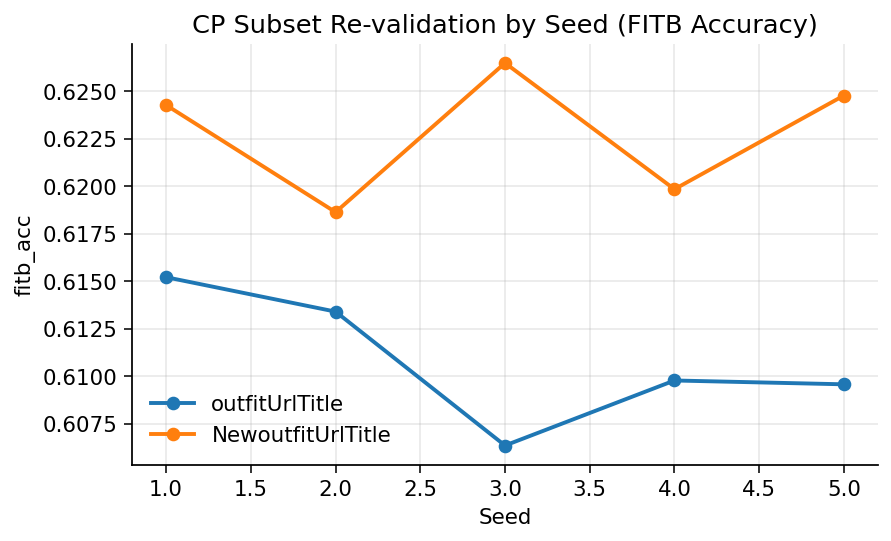

[saved] ./analysis_outputs/figures/cir_subset_revalidation_r10.png


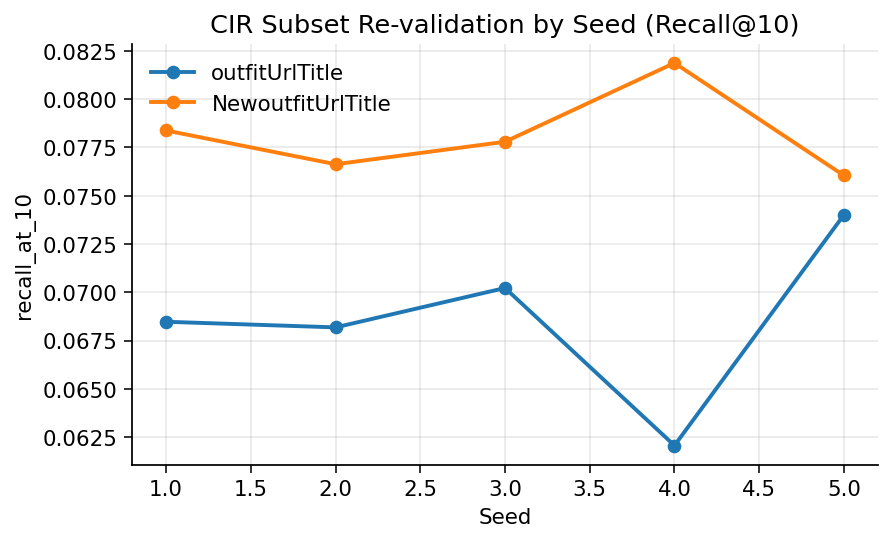

[saved] ./analysis_outputs/figures/cp_factor_contribution_by_seed_fitb.png


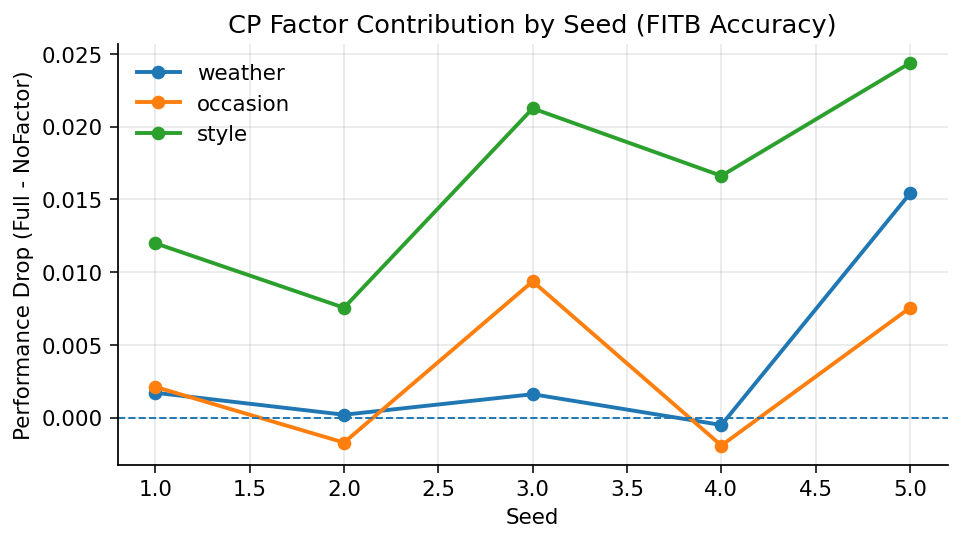

[saved] ./analysis_outputs/figures/cir_factor_contribution_by_seed_r10.png


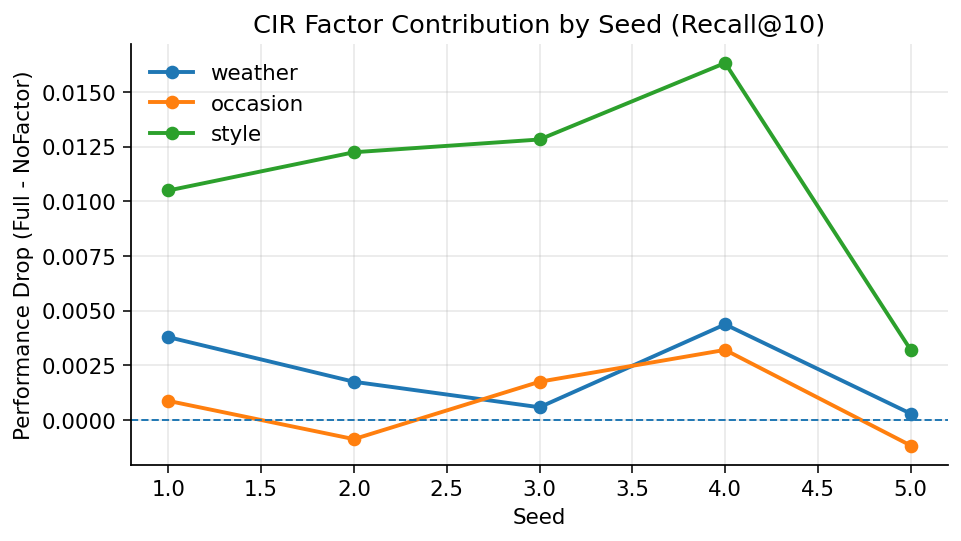

[saved] ./analysis_outputs/figures/cp_factor_contribution_bar_fitb.png


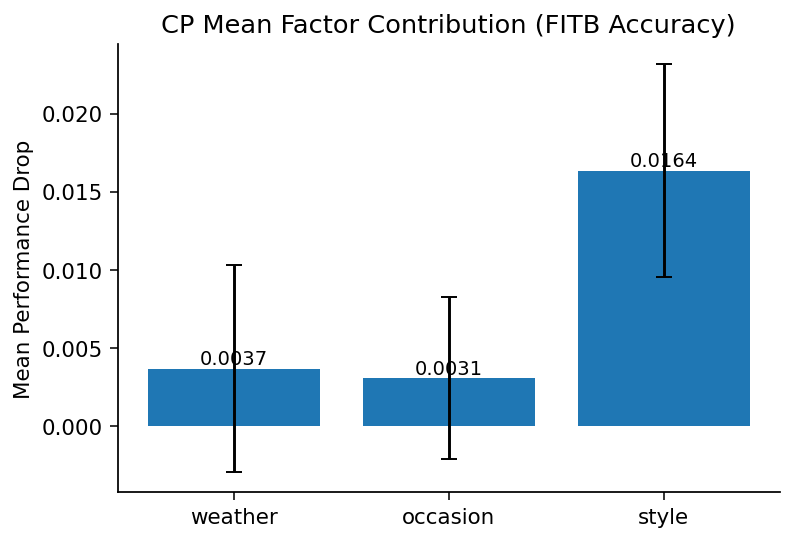

[saved] ./analysis_outputs/figures/cir_factor_contribution_bar_r10.png


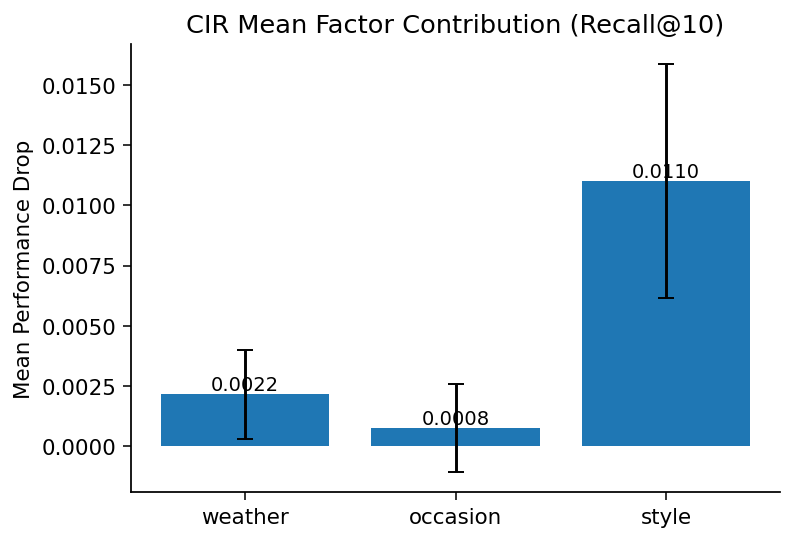

[saved] ./analysis_outputs/figures/cp_subset_revalidation_auc.png


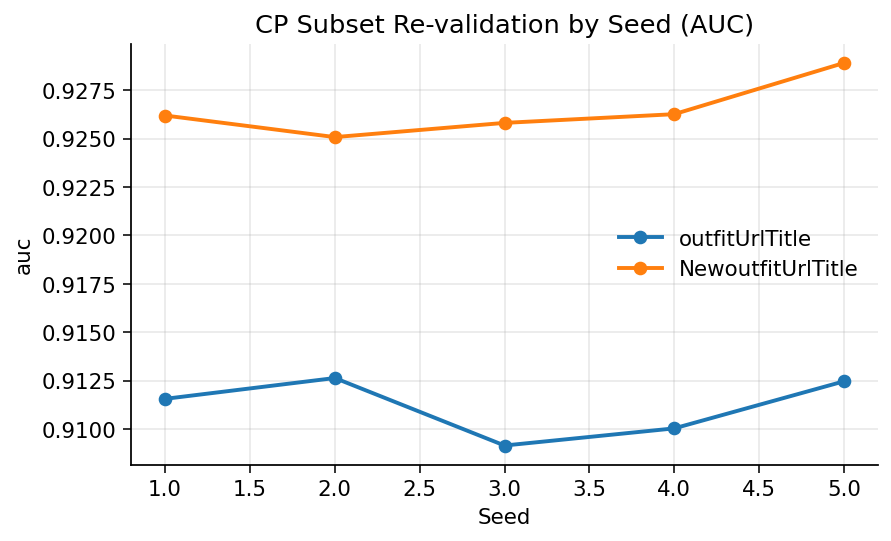

[saved] ./analysis_outputs/figures/cir_subset_revalidation_r30.png


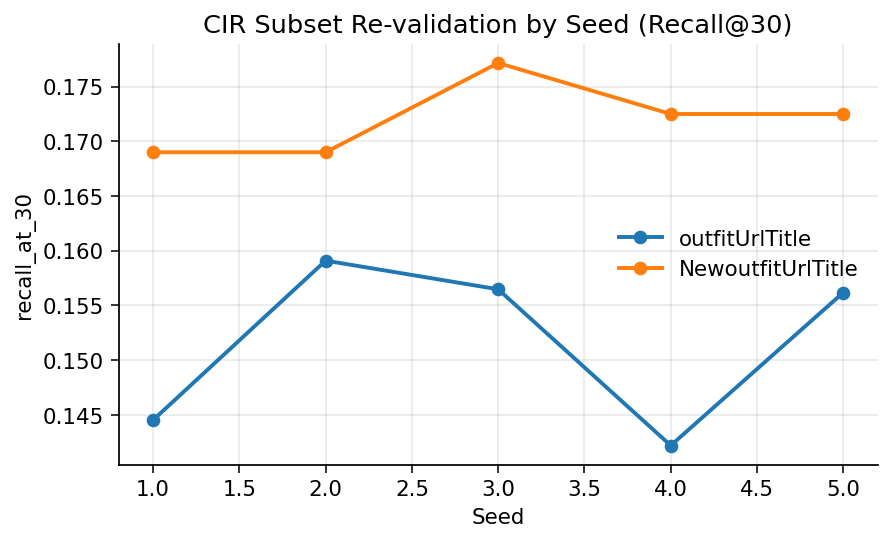

[saved] ./analysis_outputs/figures/cir_subset_revalidation_r50.png


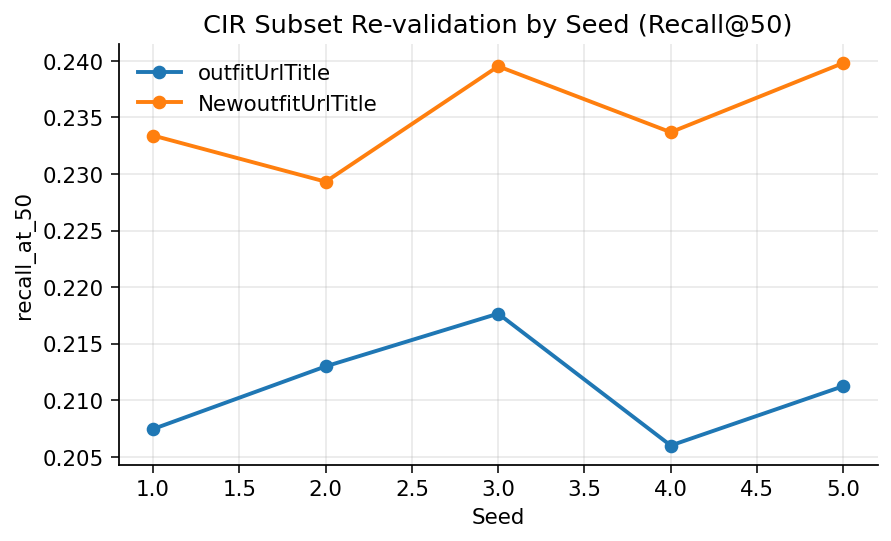

[saved] ./analysis_outputs/figures/cp_factor_contribution_by_seed_auc.png


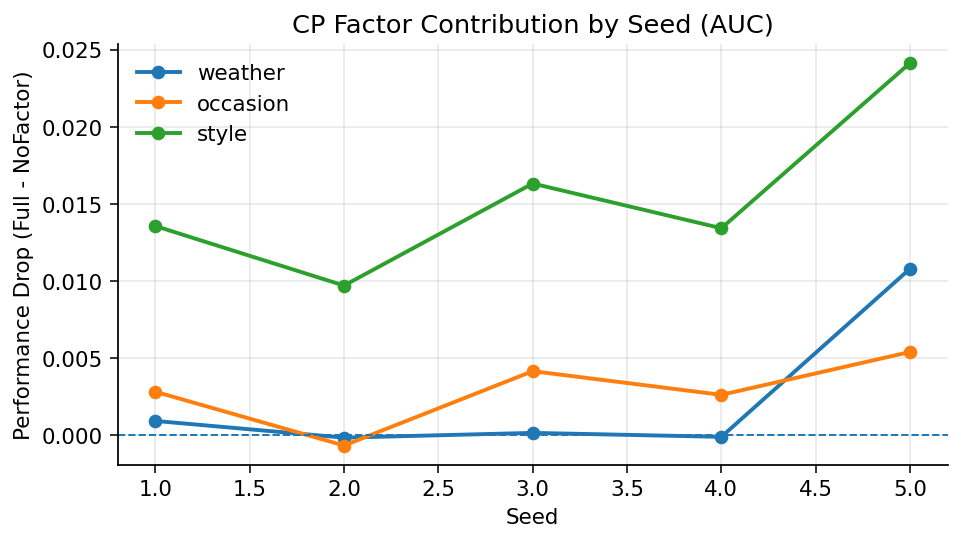

[saved] ./analysis_outputs/figures/cir_factor_contribution_by_seed_r30.png


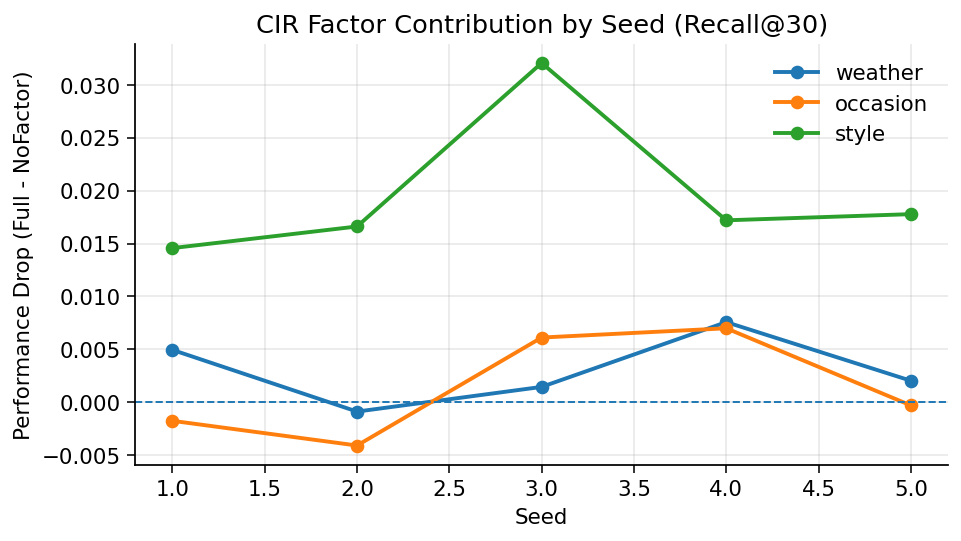

[saved] ./analysis_outputs/figures/cir_factor_contribution_by_seed_r50.png


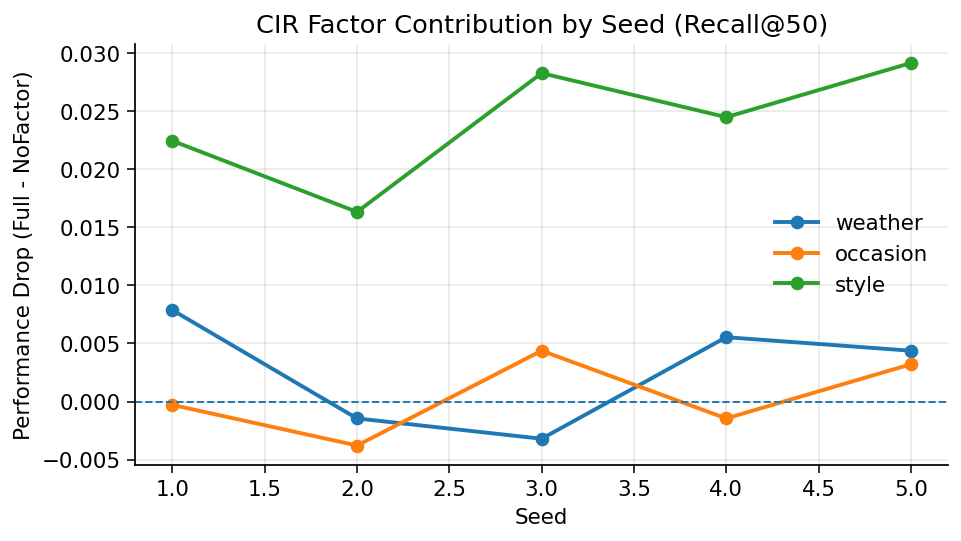

[saved] ./analysis_outputs/figures/cp_factor_contribution_bar_auc.png


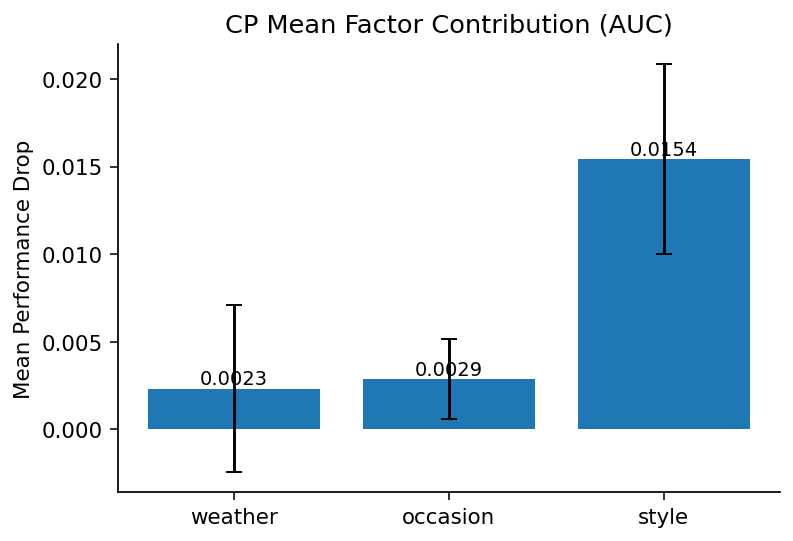

[saved] ./analysis_outputs/figures/cir_factor_contribution_bar_r30.png


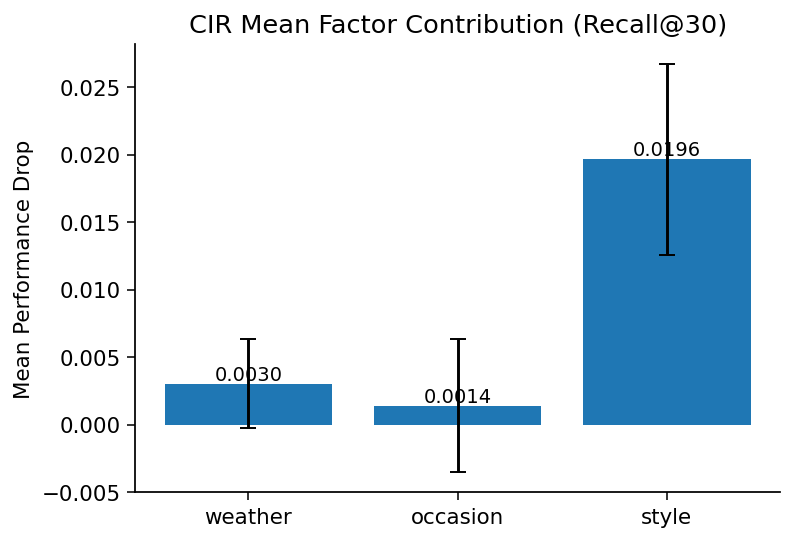

[saved] ./analysis_outputs/figures/cir_factor_contribution_bar_r50.png


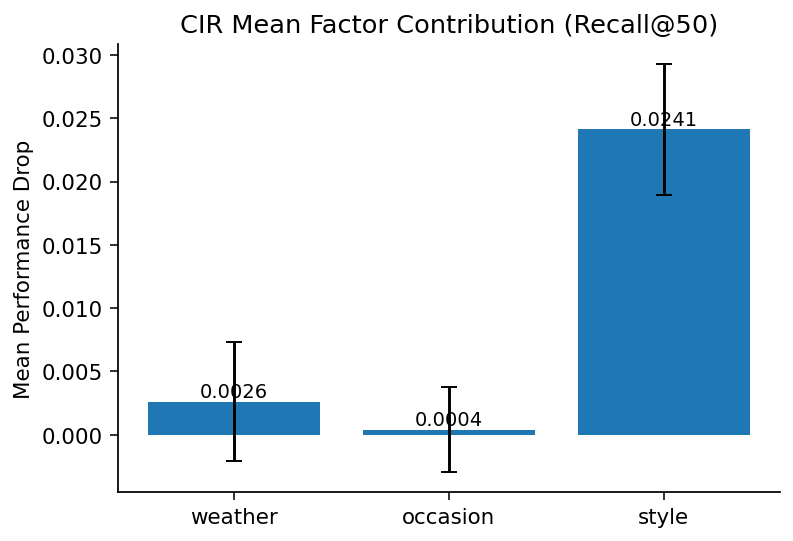


=== Factor Ranking ===


,task,metric,factor,mean_drop,std_drop,positive_seeds,n,relative_importance_pct,rank_by_mean_drop
0,CIR,recall_at_10,style,0.011014,0.004851,5,5,115.243902,1.0
1,CIR,recall_at_10,weather,0.002156,0.001850,5,5,22.560976,2.0
2,CIR,recall_at_10,occasion,0.000758,0.001827,3,5,7.926829,3.0
3,CIR,recall_at_30,style,0.019639,0.007043,5,5,96.561605,1.0
4,CIR,recall_at_30,weather,0.003030,0.003281,4,5,14.899713,2.0
5,CIR,recall_at_30,occasion,0.001399,0.004908,2,5,6.876791,3.0
6,CIR,recall_at_50,style,0.024126,0.005152,5,5,100.242131,1.0
7,CIR,recall_at_50,weather,0.002622,0.004734,3,5,10.895884,2.0
8,CIR,recall_at_50,occasion,0.000408,0.003358,2,5,1.694915,3.0
9,CP,auc,style,0.015430,0.005403,5,5,100.927171,1.0



已輸出分析表格到: ./analysis_outputs/
已輸出圖檔到: ./analysis_outputs/figures/


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
from IPython.display import display

# =========================================================
# 0) 基本設定
# =========================================================
EXP_ROOT = "./experiments_none_only"
CP_CSV = os.path.join(EXP_ROOT, "results_cp.csv")
CIR_CSV = os.path.join(EXP_ROOT, "results_cir.csv")

SUBSET_TAG = "subset"
CIR_RUN_TAG = "none_subset"

ORIGINAL = "outfitUrlTitle"
FULL = "NewoutfitUrlTitle"
ABLATIONS = ["no_weather", "no_occasion", "no_style"]

# 主指標 / 次指標
CP_PRIMARY = ["fitb_acc"]
CP_SECONDARY = ["auc"]

CIR_PRIMARY = ["recall_at_10"]
CIR_SECONDARY = ["recall_at_30", "recall_at_50"]

CP_METRICS = CP_PRIMARY + CP_SECONDARY
CIR_METRICS = CIR_PRIMARY + CIR_SECONDARY

OUTPUT_DIR = "./analysis_outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


# =========================================================
# 1) 載入與清理資料
# =========================================================
if not os.path.exists(CP_CSV):
    raise FileNotFoundError(f"找不到 {CP_CSV}")
if not os.path.exists(CIR_CSV):
    raise FileNotFoundError(f"找不到 {CIR_CSV}")

df_cp = pd.read_csv(CP_CSV)
df_cir = pd.read_csv(CIR_CSV)

# 只保留公平比較用的 subset
df_cp = df_cp[df_cp["subset_tag"] == SUBSET_TAG].copy()
df_cir = df_cir[df_cir["subset_tag"] == SUBSET_TAG].copy()

# CIR 再保留對應 run_tag
if "run_tag" in df_cir.columns:
    df_cir = df_cir[df_cir["run_tag"] == CIR_RUN_TAG].copy()

# 避免 append 重跑造成重複列
df_cp = df_cp.drop_duplicates(subset=["seed", "variant", "subset_tag"], keep="last")
df_cir = df_cir.drop_duplicates(subset=["seed", "variant", "subset_tag", "run_tag"], keep="last")

print("=== Loaded Data ===")
print("CP seeds:", sorted(df_cp["seed"].unique()))
print("CP variants:", sorted(df_cp["variant"].unique()))
print("CIR seeds:", sorted(df_cir["seed"].unique()))
print("CIR variants:", sorted(df_cir["variant"].unique()))


# =========================================================
# 2) Summary table
# =========================================================
def summarize(df, metrics):
    rows = []
    for v in sorted(df["variant"].unique()):
        dv = df[df["variant"] == v].copy()
        row = {"variant": v, "n": len(dv)}
        for m in metrics:
            vals = pd.to_numeric(dv[m], errors="coerce").to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            row[f"{m}_mean"] = vals.mean() if len(vals) else np.nan
            row[f"{m}_std"] = vals.std(ddof=1) if len(vals) >= 2 else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

cp_summary = summarize(df_cp, CP_METRICS)
cir_summary = summarize(df_cir, CIR_METRICS)

print("\n=== CP Summary ===")
display(cp_summary)

print("\n=== CIR Summary ===")
display(cir_summary)


# =========================================================
# 3) 統計工具函式
# =========================================================
def align_variants(df, variant_a, variant_b, metric):
    """
    依 seed 對齊兩個 variant 的同一個 metric
    """
    a = df[df["variant"] == variant_a][["seed", metric]].rename(columns={metric: "A"})
    b = df[df["variant"] == variant_b][["seed", metric]].rename(columns={metric: "B"})
    merged = a.merge(b, on="seed", how="inner").sort_values("seed").reset_index(drop=True)
    return merged

def cohens_dz(x, y):
    diff = y - x
    if len(diff) < 2:
        return np.nan
    sd = diff.std(ddof=1)
    if sd == 0:
        return np.nan
    return diff.mean() / sd

def compare_variants_row(df, metric, baseline, target, task, section):
    """
    section:
      - subset_validation
      - factor_ablation
    """
    merged = align_variants(df, baseline, target, metric)
    x = merged["A"].to_numpy(dtype=float)
    y = merged["B"].to_numpy(dtype=float)
    diff = y - x

    if len(x) < 2:
        return {
            "task": task,
            "section": section,
            "metric": metric,
            "baseline": baseline,
            "target": target,
            "n": len(x),
            "paired_seeds": merged["seed"].tolist(),
            "baseline_mean": np.mean(x) if len(x) else np.nan,
            "baseline_std": np.std(x, ddof=1) if len(x) > 1 else np.nan,
            "target_mean": np.mean(y) if len(y) else np.nan,
            "target_std": np.std(y, ddof=1) if len(y) > 1 else np.nan,
            "delta_mean": np.mean(diff) if len(diff) else np.nan,
            "delta_std": np.std(diff, ddof=1) if len(diff) > 1 else np.nan,
            "p_ttest": np.nan,
            "p_wilcoxon": np.nan,
            "cohens_dz": np.nan,
        }

    t_stat, p_t = ttest_rel(y, x)
    try:
        _, p_w = wilcoxon(y, x, zero_method="wilcox", correction=False)
    except Exception:
        p_w = np.nan

    return {
        "task": task,
        "section": section,
        "metric": metric,
        "baseline": baseline,
        "target": target,
        "n": len(x),
        "paired_seeds": merged["seed"].tolist(),
        "baseline_mean": x.mean(),
        "baseline_std": x.std(ddof=1),
        "target_mean": y.mean(),
        "target_std": y.std(ddof=1),
        "delta_mean": diff.mean(),
        "delta_std": diff.std(ddof=1),
        "p_ttest": p_t,
        "p_wilcoxon": p_w,
        "cohens_dz": cohens_dz(x, y),
    }

def holm_bonferroni(pvals):
    """
    Holm-Bonferroni adjusted p-values
    """
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    adjusted = np.empty(n, dtype=float)

    running_max = 0.0
    for rank, idx in enumerate(order):
        adj = (n - rank) * pvals[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted

def add_significance_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""


# =========================================================
# 4) Section A：縮減子集再驗證
#    ORIGINAL vs FULL
# =========================================================
subset_validation_rows = []

for metric in CP_METRICS:
    subset_validation_rows.append(
        compare_variants_row(
            df_cp,
            metric=metric,
            baseline=ORIGINAL,
            target=FULL,
            task="CP",
            section="subset_validation"
        )
    )

for metric in CIR_METRICS:
    subset_validation_rows.append(
        compare_variants_row(
            df_cir,
            metric=metric,
            baseline=ORIGINAL,
            target=FULL,
            task="CIR",
            section="subset_validation"
        )
    )

subset_validation_df = pd.DataFrame(subset_validation_rows)

# 依 task 分別做 Holm 校正（比較合理）
subset_validation_df["p_ttest_holm"] = np.nan
subset_validation_df["p_wilcoxon_holm"] = np.nan

for task in subset_validation_df["task"].unique():
    idx = subset_validation_df["task"] == task
    subset_validation_df.loc[idx, "p_ttest_holm"] = holm_bonferroni(
        subset_validation_df.loc[idx, "p_ttest"].fillna(1.0).values
    )
    subset_validation_df.loc[idx, "p_wilcoxon_holm"] = holm_bonferroni(
        subset_validation_df.loc[idx, "p_wilcoxon"].fillna(1.0).values
    )

subset_validation_df["sig_ttest_holm"] = subset_validation_df["p_ttest_holm"].apply(add_significance_stars)
subset_validation_df["sig_wilcoxon_holm"] = subset_validation_df["p_wilcoxon_holm"].apply(add_significance_stars)

print("\n=== Section A：縮減子集再驗證 ===")
display(subset_validation_df)


# =========================================================
# 5) Section B：因子貢獻檢定
#    FULL vs no_weather / no_occasion / no_style
# =========================================================
ablation_rows = []

for ab in ABLATIONS:
    for metric in CP_METRICS:
        ablation_rows.append(
            compare_variants_row(
                df_cp,
                metric=metric,
                baseline=FULL,
                target=ab,
                task="CP",
                section="factor_ablation"
            )
        )

    for metric in CIR_METRICS:
        ablation_rows.append(
            compare_variants_row(
                df_cir,
                metric=metric,
                baseline=FULL,
                target=ab,
                task="CIR",
                section="factor_ablation"
            )
        )

ablation_test_df = pd.DataFrame(ablation_rows)

# 依 task 分別做 Holm 校正
ablation_test_df["p_ttest_holm"] = np.nan
ablation_test_df["p_wilcoxon_holm"] = np.nan

for task in ablation_test_df["task"].unique():
    idx = ablation_test_df["task"] == task
    ablation_test_df.loc[idx, "p_ttest_holm"] = holm_bonferroni(
        ablation_test_df.loc[idx, "p_ttest"].fillna(1.0).values
    )
    ablation_test_df.loc[idx, "p_wilcoxon_holm"] = holm_bonferroni(
        ablation_test_df.loc[idx, "p_wilcoxon"].fillna(1.0).values
    )

ablation_test_df["sig_ttest_holm"] = ablation_test_df["p_ttest_holm"].apply(add_significance_stars)
ablation_test_df["sig_wilcoxon_holm"] = ablation_test_df["p_wilcoxon_holm"].apply(add_significance_stars)

print("\n=== Section B：因子貢獻檢定 ===")
display(ablation_test_df)


# =========================================================
# 6) 因子貢獻表（drop / relative importance / consistency）
# =========================================================
def factor_drop_table(df, metrics, task_name):
    rows = []
    for metric in metrics:
        full_df = df[df["variant"] == FULL][["seed", metric]].rename(columns={metric: "full"})
        ori_df = df[df["variant"] == ORIGINAL][["seed", metric]].rename(columns={metric: "orig"})
        full_vs_orig = full_df.merge(ori_df, on="seed", how="inner")
        total_gain = (full_vs_orig["full"] - full_vs_orig["orig"]).mean()

        for ab in ABLATIONS:
            ab_df = df[df["variant"] == ab][["seed", metric]].rename(columns={metric: "ab"})
            merged = full_df.merge(ab_df, on="seed", how="inner")
            drop = merged["full"] - merged["ab"]

            rows.append({
                "task": task_name,
                "metric": metric,
                "factor": ab.replace("no_", ""),
                "mean_drop": drop.mean(),
                "std_drop": drop.std(ddof=1) if len(drop) >= 2 else np.nan,
                "positive_seeds": int((drop > 0).sum()),
                "n": len(drop),
                "relative_importance": (drop.mean() / total_gain) if total_gain != 0 else np.nan,
                "relative_importance_pct": ((drop.mean() / total_gain) * 100.0) if total_gain != 0 else np.nan,
                "drops": drop.tolist(),
            })
    return pd.DataFrame(rows)

cp_drop = factor_drop_table(df_cp, CP_METRICS, "CP")
cir_drop = factor_drop_table(df_cir, CIR_METRICS, "CIR")

print("\n=== CP Factor Contribution ===")
display(cp_drop.drop(columns=["drops"]))

print("\n=== CIR Factor Contribution ===")
display(cir_drop.drop(columns=["drops"]))


# =========================================================
# 7) 建立 seed-level 因子 drop（畫圖用）
# =========================================================
def build_factor_drop_by_seed(df, metrics, task_name):
    rows = []
    for metric in metrics:
        full_df = df[df["variant"] == FULL][["seed", metric]].rename(columns={metric: "full"})
        for ab in ABLATIONS:
            ab_df = df[df["variant"] == ab][["seed", metric]].rename(columns={metric: "ab"})
            merged = full_df.merge(ab_df, on="seed", how="inner")
            merged["drop"] = merged["full"] - merged["ab"]
            merged["factor"] = ab.replace("no_", "")
            merged["metric"] = metric
            merged["task"] = task_name
            rows.append(merged[["seed", "factor", "metric", "task", "drop"]])
    return pd.concat(rows, axis=0, ignore_index=True)

cp_drop_by_seed = build_factor_drop_by_seed(df_cp, CP_METRICS, "CP")
cir_drop_by_seed = build_factor_drop_by_seed(df_cir, CIR_METRICS, "CIR")


# =========================================================
# 8) 視覺化函式
# =========================================================
def save_current_fig(filename):
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, bbox_inches="tight")
    print(f"[saved] {path}")

def plot_revalidation_by_seed(df, metric, title, save_name=None):
    """
    Section A:
    x 軸 = seed
    兩條線 = ORIGINAL, FULL
    """
    d = df[df["variant"].isin([ORIGINAL, FULL])].copy()
    pivot = d.pivot(index="seed", columns="variant", values=metric).sort_index()

    fig, ax = plt.subplots(figsize=(6.5, 4))
    for variant in [ORIGINAL, FULL]:
        if variant in pivot.columns:
            ax.plot(pivot.index, pivot[variant], marker="o", linewidth=2, label=variant)

    ax.set_xlabel("Seed")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_name:
        save_current_fig(save_name)
    plt.show()

def plot_factor_drop_by_seed(drop_by_seed_df, metric, title, save_name=None):
    """
    Section B 主圖:
    x 軸 = seed
    y 軸 = Full - NoFactor
    三條線 = weather / occasion / style
    """
    d = drop_by_seed_df[drop_by_seed_df["metric"] == metric].copy()
    pivot = d.pivot(index="seed", columns="factor", values="drop").sort_index()

    order = ["weather", "occasion", "style"]

    fig, ax = plt.subplots(figsize=(7.0, 4))
    for factor in order:
        if factor in pivot.columns:
            ax.plot(pivot.index, pivot[factor], marker="o", linewidth=2, label=factor)

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xlabel("Seed")
    ax.set_ylabel("Performance Drop (Full - NoFactor)")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_name:
        save_current_fig(save_name)
    plt.show()

def plot_factor_drop_bar(drop_df, metric, title, save_name=None):
    """
    輔助摘要圖:
    x 軸 = factor
    y 軸 = mean drop
    """
    d = drop_df[drop_df["metric"] == metric].copy()
    order = ["weather", "occasion", "style"]
    d["factor"] = pd.Categorical(d["factor"], categories=order, ordered=True)
    d = d.sort_values("factor")

    fig, ax = plt.subplots(figsize=(5.8, 4))
    x = np.arange(len(d))
    ax.bar(x, d["mean_drop"], yerr=d["std_drop"], capsize=4)

    ax.set_xticks(x)
    ax.set_xticklabels(d["factor"])
    ax.set_ylabel("Mean Performance Drop")
    ax.set_title(title)

    for i, row in enumerate(d.itertuples()):
        y = row.mean_drop if pd.notna(row.mean_drop) else 0.0
        ax.text(i, y, f"{row.mean_drop:.4f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()

    if save_name:
        save_current_fig(save_name)
    plt.show()


# =========================================================
# 9) 正文建議圖
# =========================================================
# Section A：縮減子集再驗證（每個 task 放一張主圖即可）
plot_revalidation_by_seed(
    df_cp, "fitb_acc",
    "CP Subset Re-validation by Seed (FITB Accuracy)",
    save_name="cp_subset_revalidation_fitb.png"
)

plot_revalidation_by_seed(
    df_cir, "recall_at_10",
    "CIR Subset Re-validation by Seed (Recall@10)",
    save_name="cir_subset_revalidation_r10.png"
)

# Section B：因子貢獻主圖（每個 task 放一張主圖即可）
plot_factor_drop_by_seed(
    cp_drop_by_seed, "fitb_acc",
    "CP Factor Contribution by Seed (FITB Accuracy)",
    save_name="cp_factor_contribution_by_seed_fitb.png"
)

plot_factor_drop_by_seed(
    cir_drop_by_seed, "recall_at_10",
    "CIR Factor Contribution by Seed (Recall@10)",
    save_name="cir_factor_contribution_by_seed_r10.png"
)

# Section B：平均貢獻摘要圖（輔助圖）
plot_factor_drop_bar(
    cp_drop, "fitb_acc",
    "CP Mean Factor Contribution (FITB Accuracy)",
    save_name="cp_factor_contribution_bar_fitb.png"
)

plot_factor_drop_bar(
    cir_drop, "recall_at_10",
    "CIR Mean Factor Contribution (Recall@10)",
    save_name="cir_factor_contribution_bar_r10.png"
)


# =========================================================
# 10) 額外：若你想看 secondary metrics 也可以一起畫
# =========================================================
plot_revalidation_by_seed(
    df_cp, "auc",
    "CP Subset Re-validation by Seed (AUC)",
    save_name="cp_subset_revalidation_auc.png"
)

plot_revalidation_by_seed(
    df_cir, "recall_at_30",
    "CIR Subset Re-validation by Seed (Recall@30)",
    save_name="cir_subset_revalidation_r30.png"
)

plot_revalidation_by_seed(
    df_cir, "recall_at_50",
    "CIR Subset Re-validation by Seed (Recall@50)",
    save_name="cir_subset_revalidation_r50.png"
)

plot_factor_drop_by_seed(
    cp_drop_by_seed, "auc",
    "CP Factor Contribution by Seed (AUC)",
    save_name="cp_factor_contribution_by_seed_auc.png"
)

plot_factor_drop_by_seed(
    cir_drop_by_seed, "recall_at_30",
    "CIR Factor Contribution by Seed (Recall@30)",
    save_name="cir_factor_contribution_by_seed_r30.png"
)

plot_factor_drop_by_seed(
    cir_drop_by_seed, "recall_at_50",
    "CIR Factor Contribution by Seed (Recall@50)",
    save_name="cir_factor_contribution_by_seed_r50.png"
)

plot_factor_drop_bar(
    cp_drop, "auc",
    "CP Mean Factor Contribution (AUC)",
    save_name="cp_factor_contribution_bar_auc.png"
)

plot_factor_drop_bar(
    cir_drop, "recall_at_30",
    "CIR Mean Factor Contribution (Recall@30)",
    save_name="cir_factor_contribution_bar_r30.png"
)

plot_factor_drop_bar(
    cir_drop, "recall_at_50",
    "CIR Mean Factor Contribution (Recall@50)",
    save_name="cir_factor_contribution_bar_r50.png"
)


# =========================================================
# 11) 排名表：哪個因子最重要
# =========================================================
def build_factor_ranking(drop_df):
    out = drop_df.copy()
    out["rank_by_mean_drop"] = out.groupby(["task", "metric"])["mean_drop"].rank(
        ascending=False, method="dense"
    )
    return out.sort_values(["task", "metric", "rank_by_mean_drop", "factor"]).reset_index(drop=True)

factor_ranking_df = build_factor_ranking(pd.concat([cp_drop, cir_drop], axis=0))
print("\n=== Factor Ranking ===")
display(
    factor_ranking_df[
        ["task", "metric", "factor", "mean_drop", "std_drop", "positive_seeds", "n", "relative_importance_pct", "rank_by_mean_drop"]
    ]
)


# =========================================================
# 12) 匯出表格
# =========================================================
cp_summary.to_csv(os.path.join(OUTPUT_DIR, "cp_summary_subset.csv"), index=False)
cir_summary.to_csv(os.path.join(OUTPUT_DIR, "cir_summary_subset.csv"), index=False)

subset_validation_df.to_csv(os.path.join(OUTPUT_DIR, "subset_validation_stats.csv"), index=False)
ablation_test_df.to_csv(os.path.join(OUTPUT_DIR, "factor_ablation_stats.csv"), index=False)

cp_drop.to_csv(os.path.join(OUTPUT_DIR, "cp_factor_drop.csv"), index=False)
cir_drop.to_csv(os.path.join(OUTPUT_DIR, "cir_factor_drop.csv"), index=False)
factor_ranking_df.to_csv(os.path.join(OUTPUT_DIR, "factor_ranking.csv"), index=False)

print(f"\n已輸出分析表格到: {OUTPUT_DIR}/")
print(f"已輸出圖檔到: {FIG_DIR}/")

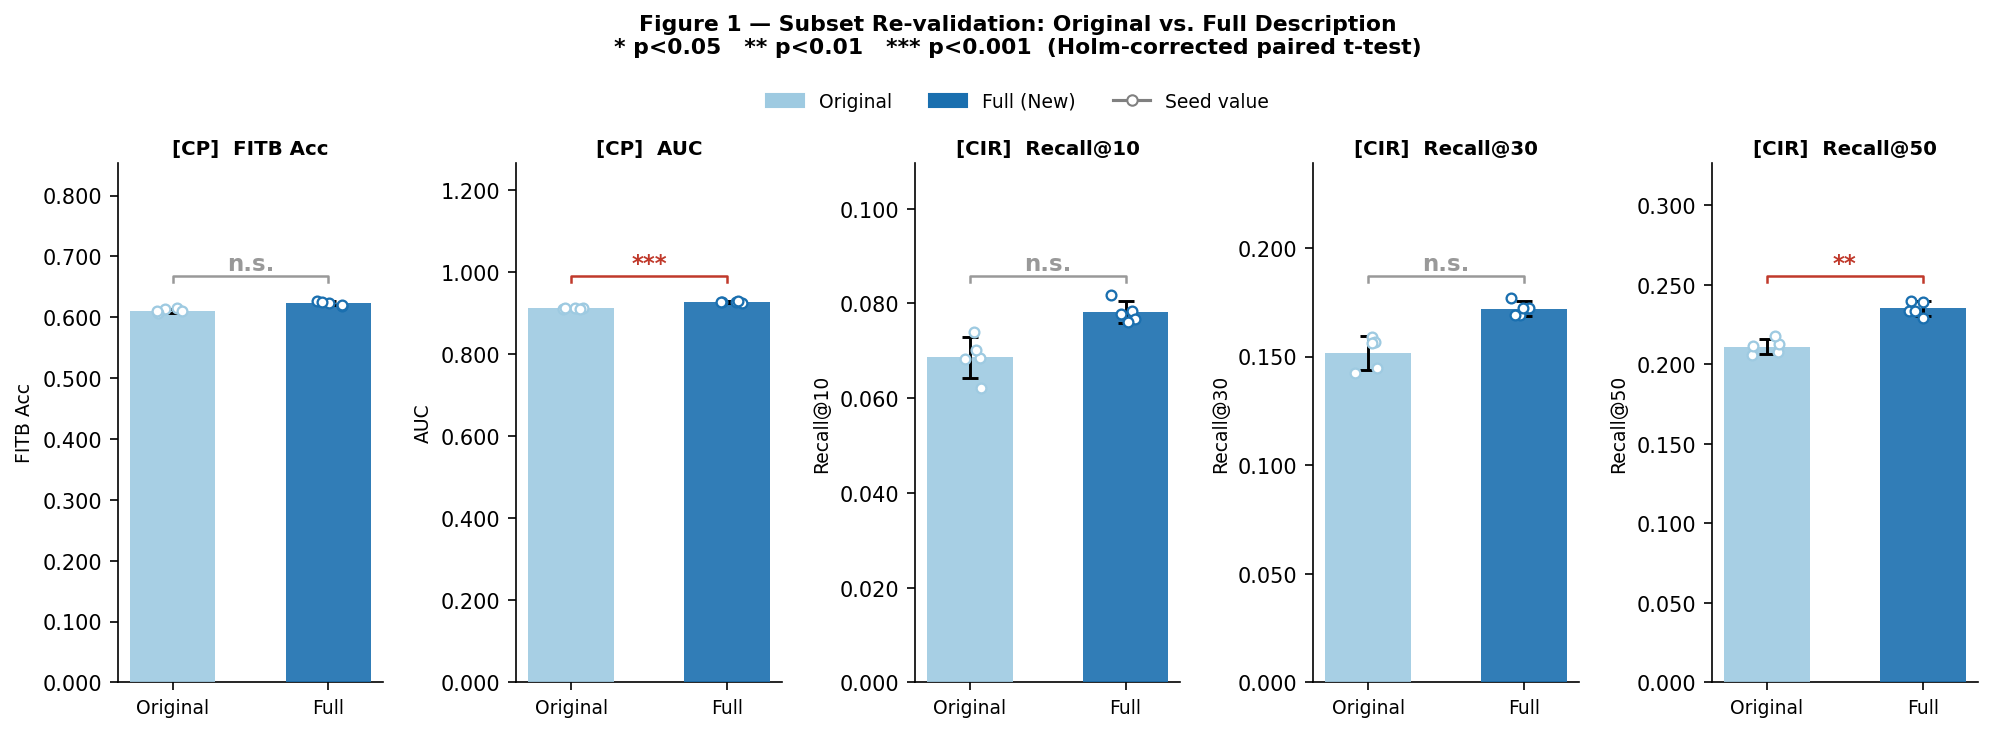

[儲存] fig1_subset_validation


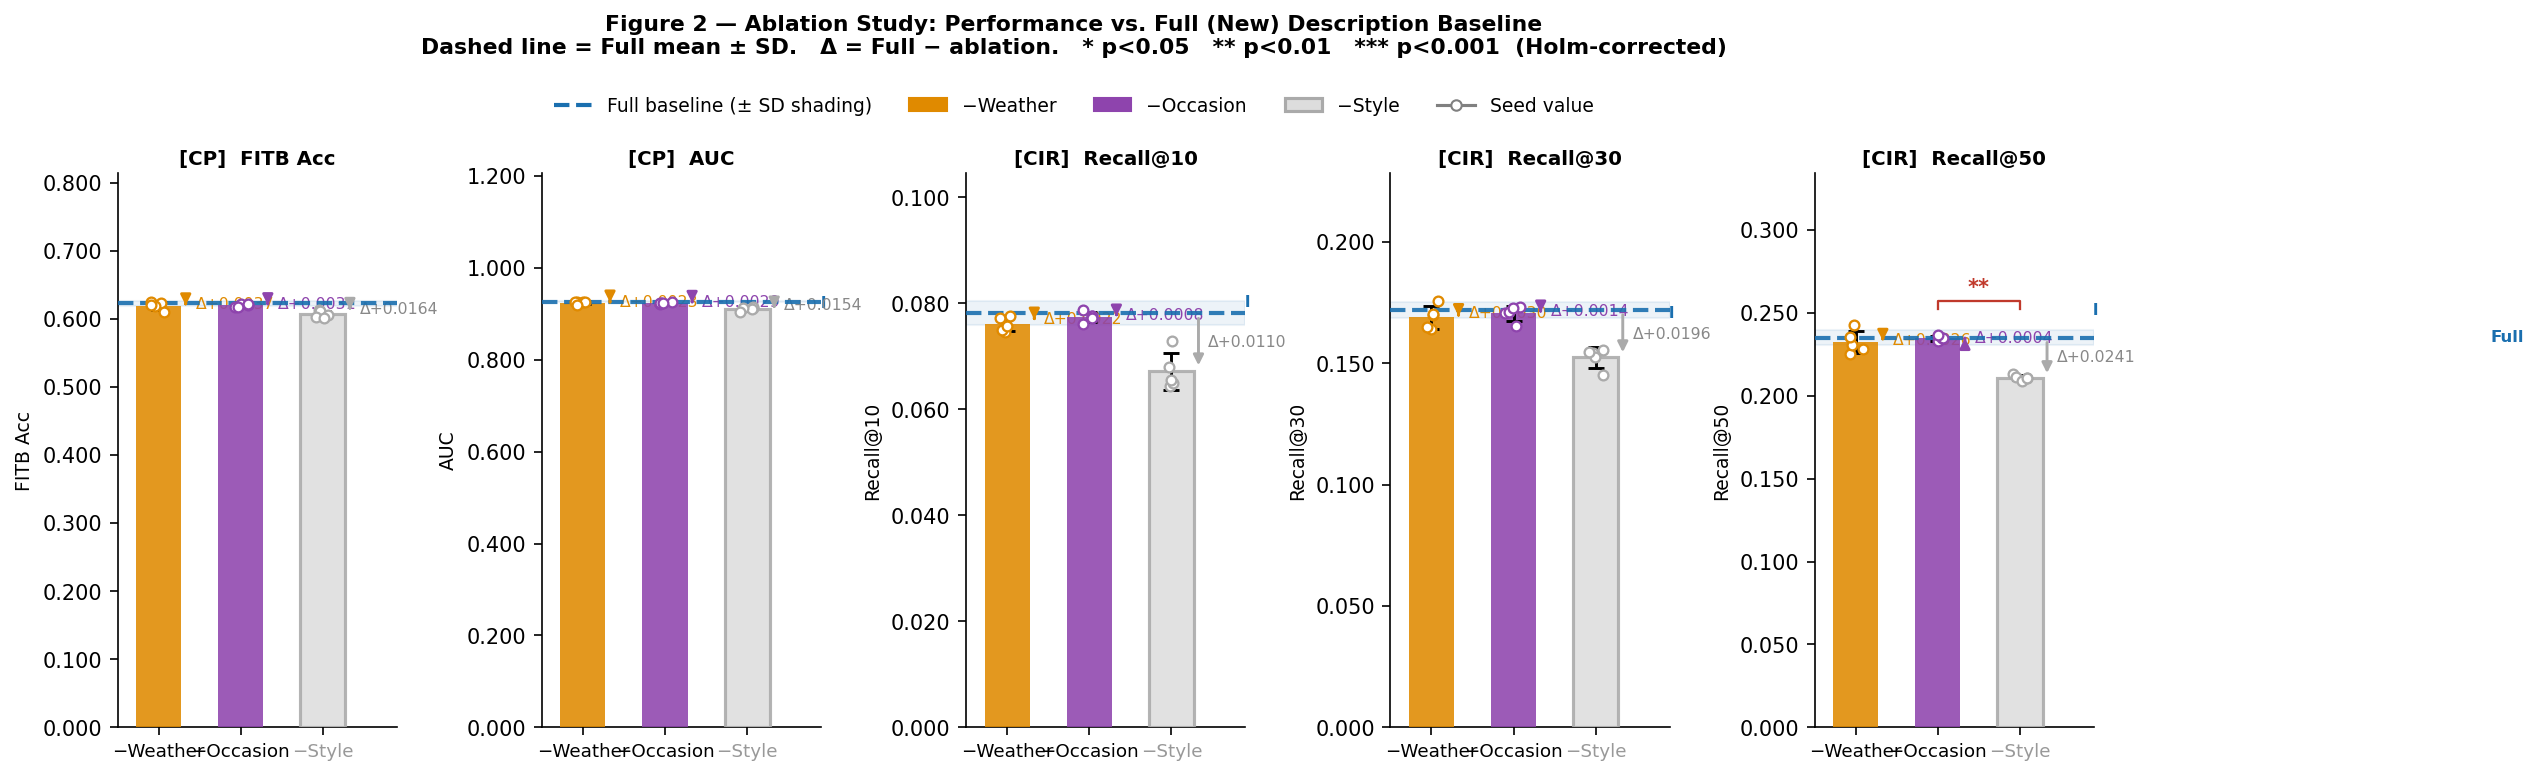

[儲存] fig2_ablation


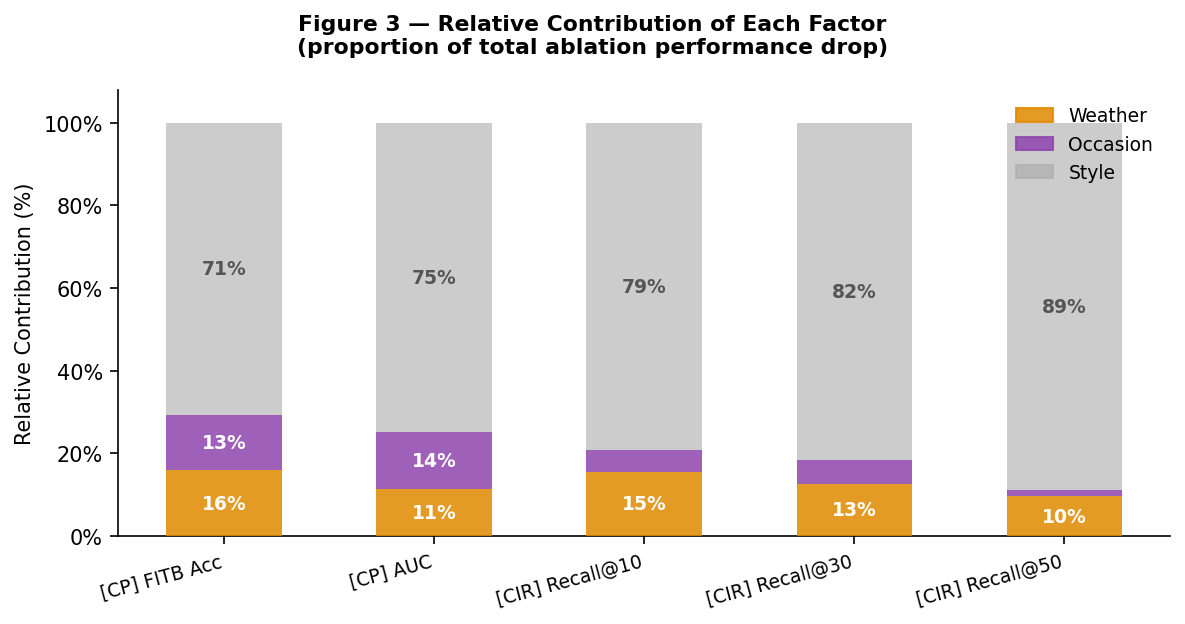

[儲存] fig3_factor_proportion


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from scipy.stats import ttest_rel

# ── 路徑設定 ─────────────────────────────────────────────────
EXP_ROOT    = "./experiments_none_only"
CP_CSV      = os.path.join(EXP_ROOT, "results_cp.csv")
CIR_CSV     = os.path.join(EXP_ROOT, "results_cir.csv")
SUBSET_TAG  = "subset"
CIR_RUN_TAG = "none_subset"
ORIGINAL    = "outfitUrlTitle"
FULL        = "NewoutfitUrlTitle"
ABLATIONS   = ["no_weather", "no_occasion", "no_style"]
CP_METRICS  = ["fitb_acc", "auc"]
CIR_METRICS = ["recall_at_10", "recall_at_30", "recall_at_50"]
OUTPUT_DIR  = "./analysis_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

C_ORIG    = "#9ecae1"
C_FULL    = "#1a6faf"
C_WEATHER = "#e08a00"
C_OCCAS   = "#8e44ad"
C_STYLE   = "#aaaaaa"

AB_COLORS = {"no_weather": C_WEATHER, "no_occasion": C_OCCAS, "no_style": C_STYLE}
AB_LABELS = {"no_weather": "−Weather", "no_occasion": "−Occasion", "no_style": "−Style"}

METRIC_LABELS = {
    "fitb_acc":     "FITB Acc",
    "auc":          "AUC",
    "recall_at_10": "Recall@10",
    "recall_at_30": "Recall@30",
    "recall_at_50": "Recall@50",
}

# ── 資料載入 ─────────────────────────────────────────────────
df_cp  = pd.read_csv(CP_CSV)
df_cir = pd.read_csv(CIR_CSV)
df_cp  = df_cp[df_cp["subset_tag"] == SUBSET_TAG].copy()
df_cir = df_cir[df_cir["subset_tag"] == SUBSET_TAG].copy()
if "run_tag" in df_cir.columns:
    df_cir = df_cir[df_cir["run_tag"] == CIR_RUN_TAG].copy()
df_cp  = df_cp .drop_duplicates(["seed","variant","subset_tag"],           keep="last")
df_cir = df_cir.drop_duplicates(["seed","variant","subset_tag","run_tag"], keep="last")

all_metrics = CP_METRICS + CIR_METRICS
task_map    = {m:"CP" for m in CP_METRICS}
task_map.update({m:"CIR" for m in CIR_METRICS})
df_map = {"CP": df_cp, "CIR": df_cir}

# ── 統計工具 ─────────────────────────────────────────────────
def get_vals(df, variant, metric):
    return df[df["variant"]==variant][metric].dropna().values

def align(df, va, vb, metric):
    a = df[df["variant"]==va][["seed",metric]].rename(columns={metric:"A"})
    b = df[df["variant"]==vb][["seed",metric]].rename(columns={metric:"B"})
    return a.merge(b, on="seed", how="inner").sort_values("seed").reset_index(drop=True)

def paired_p(df, va, vb, metric):
    m = align(df, va, vb, metric)
    if len(m) < 2: return np.nan
    _, p = ttest_rel(m["B"].values, m["A"].values)
    return p

def holm(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n, order = len(pvals), np.argsort(pvals)
    adj, run = np.empty(n), 0.0
    for rank, idx in enumerate(order):
        run = max(run, (n-rank)*pvals[idx])
        adj[idx] = min(run, 1.0)
    return adj

def stars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "n.s."

# Holm 校正
raw_ps, p_keys = [], []
for metric in all_metrics:
    df = df_map[task_map[metric]]
    raw_ps.append(paired_p(df, ORIGINAL, FULL, metric))
    p_keys.append(("secA", metric))
    for ab in ABLATIONS:
        raw_ps.append(paired_p(df, FULL, ab, metric))
        p_keys.append(("secB", metric, ab))
adj_ps = holm(np.where(np.isnan(raw_ps), 1.0, raw_ps))
p_map  = {k: adj_ps[i] for i, k in enumerate(p_keys)}


# ════════════════════════════════════════════════════════════
#  Figure 1 — Section A：Original vs Full
# ════════════════════════════════════════════════════════════
def draw_sig_bracket(ax, x0, x1, y, s, color):
    h = y * 0.015
    ax.plot([x0, x0, x1, x1], [y, y+h, y+h, y], color=color, lw=1.2)
    ax.text((x0+x1)/2, y+h*1.2, s,
            ha="center", va="bottom", fontsize=11,
            fontweight="bold", color=color)

fig1, axes = plt.subplots(
    1, len(all_metrics),
    figsize=(3.2*len(all_metrics), 4.5),
    gridspec_kw={"wspace": 0.5}
)

for col_i, (ax, metric) in enumerate(zip(axes, all_metrics)):
    task = task_map[metric]
    df   = df_map[task]

    v_orig = get_vals(df, ORIGINAL, metric)
    v_full = get_vals(df, FULL,     metric)
    mu_o, sd_o = v_orig.mean(), v_orig.std(ddof=1)
    mu_f, sd_f = v_full.mean(), v_full.std(ddof=1)

    ax.bar(0, mu_o, yerr=sd_o, width=0.55, color=C_ORIG, alpha=0.9,
           capsize=4, error_kw={"lw":1.4,"capthick":1.4}, zorder=3)
    ax.bar(1, mu_f, yerr=sd_f, width=0.55, color=C_FULL, alpha=0.9,
           capsize=4, error_kw={"lw":1.4,"capthick":1.4}, zorder=3)

    for xi, vals, clr in [(0, v_orig, C_ORIG), (1, v_full, C_FULL)]:
        jit = np.random.default_rng(xi+col_i*7).uniform(-0.1, 0.1, len(vals))
        ax.scatter(xi+jit, vals, color="white", edgecolors=clr,
                   s=22, lw=1.1, zorder=5)

    p_adj = p_map.get(("secA", metric), np.nan)
    s_lbl = stars(p_adj)
    y_top = max(mu_o+sd_o, mu_f+sd_f) * 1.05
    clr_s = "#c0392b" if s_lbl not in ("n.s.","") else "#999999"
    draw_sig_bracket(ax, 0, 1, y_top, s_lbl, clr_s)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Original", "Full"], fontsize=9)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.set_title(f"[{task}]  {METRIC_LABELS[metric]}",
                 fontsize=9.5, fontweight="bold", pad=4)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.margins(y=0.28)

legend1 = [
    mpatches.Patch(color=C_ORIG, label="Original"),
    mpatches.Patch(color=C_FULL, label="Full (New)"),
    mlines.Line2D([], [], marker="o", color="gray",
                  markerfacecolor="white", markersize=5, label="Seed value"),
]
fig1.legend(handles=legend1, loc="upper center", ncol=3,
            fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig1.suptitle(
    "Figure 1 — Subset Re-validation: Original vs. Full Description\n"
    "* p<0.05   ** p<0.01   *** p<0.001  (Holm-corrected paired t-test)",
    fontsize=10.5, fontweight="bold", y=1.10)

plt.savefig(os.path.join(OUTPUT_DIR, "fig1_subset_validation.pdf"))
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_subset_validation.png"))
plt.show()
print("[儲存] fig1_subset_validation")


# ════════════════════════════════════════════════════════════
#  Figure 2 — Section B：消融分析，Full 基準線明確標出
# ════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(
    1, len(all_metrics),
    figsize=(3.4*len(all_metrics), 4.8),
    gridspec_kw={"wspace": 0.52}
)

for col_i, (ax, metric) in enumerate(zip(axes2, all_metrics)):
    task = task_map[metric]
    df   = df_map[task]

    v_full  = get_vals(df, FULL, metric)
    mu_full = v_full.mean()
    sd_full = v_full.std(ddof=1)

    # Full 基準虛線 + SD 陰影
    ax.axhline(mu_full, color=C_FULL, lw=2.0, ls="--", zorder=4, alpha=0.9)
    ax.axhspan(mu_full-sd_full, mu_full+sd_full,
               color=C_FULL, alpha=0.08, zorder=1)

    # "Full" 標籤貼在虛線右端
    ax.annotate("Full", xy=(2.42, mu_full),
                xycoords=("axes fraction", "data"),
                fontsize=8, color=C_FULL, fontweight="bold",
                va="center")

    bracket_y = mu_full + sd_full  # 顯著性 bracket 起始高度

    for vi, ab in enumerate(ABLATIONS):
        xi  = vi
        clr = AB_COLORS[ab]
        v_ab = get_vals(df, ab, metric)
        if len(v_ab) == 0: continue
        mu_ab = v_ab.mean()
        sd_ab = v_ab.std(ddof=1)

        # Bar（Style 用淡色）
        fc = clr if ab != "no_style" else "#dddddd"
        ec = clr if ab == "no_style" else "none"
        ax.bar(xi, mu_ab, yerr=sd_ab, width=0.55,
               color=fc, edgecolor=ec, linewidth=1.5,
               alpha=0.88, capsize=4,
               error_kw={"lw":1.4,"capthick":1.4}, zorder=3)

        # Seed 散點
        jit = np.random.default_rng(vi+col_i*11).uniform(-0.1,0.1,len(v_ab))
        ax.scatter(xi+jit, v_ab, color="white", edgecolors=clr,
                   s=22, lw=1.1, zorder=5)

        # Δ 標注（bar 頂與 Full 線之間）
        delta = mu_full - mu_ab
        mid_y = (mu_full + mu_ab) / 2
        ax.annotate("", xy=(xi+0.33, mu_ab+sd_ab*0.1),
                    xytext=(xi+0.33, mu_full-sd_full*0.1),
                    arrowprops=dict(arrowstyle="-|>", color=clr,
                                   lw=1.4, mutation_scale=10), zorder=6)
        ax.text(xi+0.45, mid_y, f"Δ{delta:+.4f}",
                va="center", ha="left", fontsize=7.5,
                color=clr if ab != "no_style" else "#888888")

        # 顯著性 bracket（Full 基準 vs ablation）
        p_adj = p_map.get(("secB", metric, ab), np.nan)
        s_lbl = stars(p_adj)
        if s_lbl not in ("n.s.", ""):
            bk_y  = bracket_y + abs(mu_full)*0.055
            clr_s = "#c0392b"
            ax.plot([1, 1, xi, xi],
                    [bk_y, bk_y+abs(mu_full)*0.02,
                     bk_y+abs(mu_full)*0.02, bk_y],
                    color=clr_s, lw=1.1)
            ax.text((1+xi)/2, bk_y+abs(mu_full)*0.028, s_lbl,
                    ha="center", va="bottom", fontsize=10,
                    fontweight="bold", color=clr_s)
            bracket_y = bk_y + abs(mu_full)*0.04

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([AB_LABELS[a] for a in ABLATIONS], fontsize=8.8)
    ax.get_xticklabels()[2].set_color("#999999")  # Style 灰色
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.set_title(f"[{task}]  {METRIC_LABELS[metric]}",
                 fontsize=9.5, fontweight="bold", pad=4)
    ax.set_xlim(-0.5, 2.9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.margins(y=0.30)

legend2 = [
    mlines.Line2D([0],[0], color=C_FULL, lw=2, ls="--",
                  label="Full baseline (± SD shading)"),
    mpatches.Patch(color=C_WEATHER, label="−Weather"),
    mpatches.Patch(color=C_OCCAS,   label="−Occasion"),
    mpatches.Patch(facecolor="#dddddd", edgecolor=C_STYLE, lw=1.5,
                   label="−Style"),
    mlines.Line2D([], [], marker="o", color="gray",
                  markerfacecolor="white", markersize=5, label="Seed value"),
]
fig2.legend(handles=legend2, loc="upper center", ncol=5,
            fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig2.suptitle(
    "Figure 2 — Ablation Study: Performance vs. Full (New) Description Baseline\n"
    "Dashed line = Full mean ± SD.   Δ = Full − ablation.   "
    "* p<0.05   ** p<0.01   *** p<0.001  (Holm-corrected)",
    fontsize=10.5, fontweight="bold", y=1.10)

plt.savefig(os.path.join(OUTPUT_DIR, "fig2_ablation.pdf"))
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_ablation.png"))
plt.show()
print("[儲存] fig2_ablation")


# ════════════════════════════════════════════════════════════
#  Figure 3 — 因子相對貢獻比例（Stacked bar）
# ════════════════════════════════════════════════════════════
prop_rows = []
for metric in all_metrics:
    df = df_map[task_map[metric]]
    drops = {}
    for ab in ABLATIONS:
        m = align(df, FULL, ab, metric)
        drops[ab] = max((m["A"] - m["B"]).mean(), 0)
    total = sum(drops.values())
    for ab in ABLATIONS:
        prop_rows.append({
            "metric": metric,
            "factor": ab.replace("no_",""),
            "prop":   drops[ab]/total if total>0 else np.nan,
        })
prop_df = pd.DataFrame(prop_rows)

factor_order  = ["weather", "occasion", "style"]
factor_colors = {"weather": C_WEATHER, "occasion": C_OCCAS, "style": C_STYLE}
factor_labels = {"weather": "Weather", "occasion": "Occasion", "style": "Style"}
metric_x = np.arange(len(all_metrics))

fig3, ax3 = plt.subplots(figsize=(len(all_metrics)*1.6, 4.2))
bottoms = np.zeros(len(all_metrics))

for factor in factor_order:
    vals = np.array([
        prop_df[(prop_df["metric"]==m) & (prop_df["factor"]==factor)]["prop"].values[0]
        for m in all_metrics
    ])
    ax3.bar(metric_x, vals, bottom=bottoms, width=0.55,
            color=factor_colors[factor],
            alpha=0.85 if factor != "style" else 0.6,
            label=factor_labels[factor], zorder=3)
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0.07:
            ax3.text(xi, b+v/2, f"{v*100:.0f}%",
                     ha="center", va="center", fontsize=9,
                     fontweight="bold",
                     color="white" if factor != "style" else "#555")
    bottoms += vals

ax3.set_xticks(metric_x)
ax3.set_xticklabels(
    [f"[{task_map[m]}] {METRIC_LABELS[m]}" for m in all_metrics],
    fontsize=9, rotation=15, ha="right")
ax3.set_ylabel("Relative Contribution (%)", fontsize=10)
ax3.set_ylim(0, 1.08)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

legend3 = [mpatches.Patch(color=factor_colors[f], label=factor_labels[f],
                           alpha=0.85 if f!="style" else 0.6)
           for f in factor_order]
ax3.legend(handles=legend3, loc="upper right", fontsize=9, frameon=False)

fig3.suptitle(
    "Figure 3 — Relative Contribution of Each Factor\n"
    "(proportion of total ablation performance drop)",
    fontsize=10.5, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_factor_proportion.pdf"))
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_factor_proportion.png"))
plt.show()
print("[儲存] fig3_factor_proportion")

=== Loaded Data ===
CP seeds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
CP variants: ['NewoutfitUrlTitle', 'no_occasion', 'no_style', 'no_weather', 'outfitUrlTitle']
CIR seeds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
CIR variants: ['NewoutfitUrlTitle', 'no_occasion', 'no_style', 'no_weather', 'outfitUrlTitle']

=== 表 1：CP 任務－子集再驗證成對 t 檢定 ===


,Metric,Baseline (mean±std),Proposed (mean±std),Δ,p-value,Cohen’s d
0,AUC,0.9112 ± 0.0015,0.9265 ± 0.0015,+0.0153,***,8.601
1,FITB Acc,0.6109 ± 0.0035,0.6228 ± 0.0034,+0.0119,*,2.059



=== 表 2：CIR 任務－子集再驗證成對 t 檢定 ===


,Metric,Baseline (mean±std),Proposed (mean±std),Δ,p-value,Cohen’s d
0,Recall@10,0.0686 ± 0.0043,0.0781 ± 0.0023,+0.0096,*,1.479
1,Recall@30,0.1517 ± 0.0077,0.1720 ± 0.0034,+0.0203,**,2.617
2,Recall@50,0.2111 ± 0.0046,0.2351 ± 0.0045,+0.0241,***,4.774



=== 表 3：CP 任務－因子移除後的表現與下降幅度 ===


,Metric,Proposed (mean±std),No-weather (mean±std),Δ_weather,No-occasion (mean±std),Δ_occasion,No-style (mean±std),Δ_style
0,AUC,0.9265 ± 0.0015,0.9241 ± 0.0034,-0.0023,0.9236 ± 0.0015,-0.0029,0.9110 ± 0.0041,-0.0154
1,FITB Acc,0.6228 ± 0.0034,0.6191 ± 0.0060,-0.0037,0.6197 ± 0.0024,-0.0031,0.6064 ± 0.0051,-0.0164



=== 表 4：CIR 任務－因子移除後的表現與下降幅度 ===


,Metric,Proposed (mean±std),No-weather (mean±std),Δ_weather,No-occasion (mean±std),Δ_occasion,No-style (mean±std),Δ_style
0,Recall@10,0.0781 ± 0.0023,0.0760 ± 0.0013,-0.0022,0.0774 ± 0.0009,-0.0008,0.0671 ± 0.0035,-0.0110
1,Recall@30,0.1720 ± 0.0034,0.1690 ± 0.0047,-0.0030,0.1706 ± 0.0030,-0.0014,0.1524 ± 0.0042,-0.0196
2,Recall@50,0.2351 ± 0.0045,0.2325 ± 0.0068,-0.0026,0.2347 ± 0.0014,-0.0004,0.2110 ± 0.0014,-0.0241



=== 表 5：各因子的相對貢獻比例 ===


,Task,Metric,weather_loss,weather_ratio,occasion_loss,occasion_ratio,style_loss,style_ratio
0,CP,AUC,0.002329,0.112902,0.002871,0.139177,0.015430,0.747922
1,CP,FITB Acc,0.003686,0.159408,0.003082,0.133275,0.016354,0.707317
2,CIR,Recall@10,0.002156,0.154812,0.000758,0.054393,0.011014,0.790795
3,CIR,Recall@30,0.003030,0.125908,0.001399,0.058111,0.019639,0.815981
4,CIR,Recall@50,0.002622,0.096567,0.000408,0.015021,0.024126,0.888412


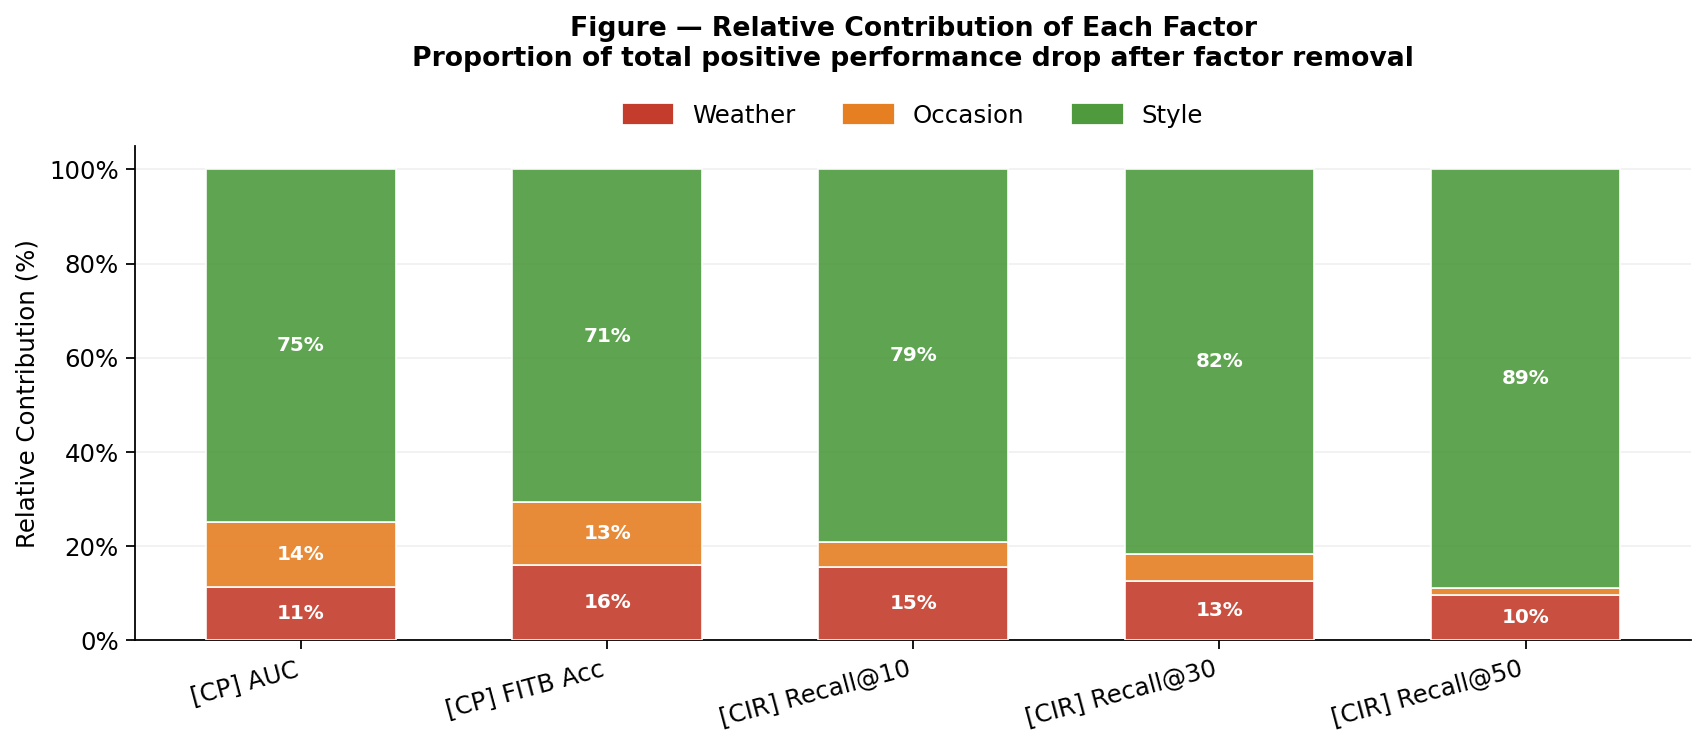

[儲存] fig3_factor_proportion

所有表格與圖已輸出到：./analysis_outputs_final


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy.stats import ttest_rel
from IPython.display import display

# =========================================================
# 0) 基本設定
# =========================================================
EXP_ROOT = "./experiments_none_only"
CP_CSV = os.path.join(EXP_ROOT, "results_cp.csv")
CIR_CSV = os.path.join(EXP_ROOT, "results_cir.csv")

SUBSET_TAG = "subset"
CIR_RUN_TAG = "none_subset"

ORIGINAL = "outfitUrlTitle"
PROPOSED = "NewoutfitUrlTitle"
ABLATIONS = ["no_weather", "no_occasion", "no_style"]

CP_METRICS = ["auc", "fitb_acc"]
CIR_METRICS = ["recall_at_10", "recall_at_30", "recall_at_50"]

OUTPUT_DIR = "./analysis_outputs_final"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 配色（比前面穩重一點）
C_BASELINE = "#9AA0A6"   # gray
C_PROPOSED = "#1F5AA6"   # blue
C_WEATHER  = "#C43C2B"   # red
C_OCCAS    = "#E67E22"   # orange
C_STYLE    = "#4E9A3D"   # green

METRIC_LABELS = {
    "auc": "AUC",
    "fitb_acc": "FITB Acc",
    "recall_at_10": "Recall@10",
    "recall_at_30": "Recall@30",
    "recall_at_50": "Recall@50",
}

TASK_MAP = {
    "auc": "CP",
    "fitb_acc": "CP",
    "recall_at_10": "CIR",
    "recall_at_30": "CIR",
    "recall_at_50": "CIR",
}

plt.rcParams["figure.dpi"] = 160
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"] = "DejaVu Sans"


# =========================================================
# 1) 載入資料
# =========================================================
if not os.path.exists(CP_CSV):
    raise FileNotFoundError(f"找不到 {CP_CSV}")
if not os.path.exists(CIR_CSV):
    raise FileNotFoundError(f"找不到 {CIR_CSV}")

df_cp = pd.read_csv(CP_CSV)
df_cir = pd.read_csv(CIR_CSV)

# 只保留公平比較用的 subset
df_cp = df_cp[df_cp["subset_tag"] == SUBSET_TAG].copy()
df_cir = df_cir[df_cir["subset_tag"] == SUBSET_TAG].copy()

# CIR 再保留對應 run_tag
if "run_tag" in df_cir.columns:
    df_cir = df_cir[df_cir["run_tag"] == CIR_RUN_TAG].copy()

# 避免 append 重跑造成重複列
df_cp = df_cp.drop_duplicates(subset=["seed", "variant", "subset_tag"], keep="last")
df_cir = df_cir.drop_duplicates(subset=["seed", "variant", "subset_tag", "run_tag"], keep="last")

print("=== Loaded Data ===")
print("CP seeds:", sorted(df_cp["seed"].unique()))
print("CP variants:", sorted(df_cp["variant"].unique()))
print("CIR seeds:", sorted(df_cir["seed"].unique()))
print("CIR variants:", sorted(df_cir["variant"].unique()))


# =========================================================
# 2) 工具函式
# =========================================================
def align(df, variant_a, variant_b, metric):
    """
    對齊同一個 seed 下兩個 variant 的同一個 metric
    回傳欄位:
      seed, A, B
    """
    a = df[df["variant"] == variant_a][["seed", metric]].rename(columns={metric: "A"})
    b = df[df["variant"] == variant_b][["seed", metric]].rename(columns={metric: "B"})
    m = a.merge(b, on="seed", how="inner").sort_values("seed").reset_index(drop=True)
    return m

def get_variant_values(df, variant, metric):
    vals = df[df["variant"] == variant][["seed", metric]].sort_values("seed")[metric].to_numpy(dtype=float)
    return vals

def mean_std_text(vals):
    vals = np.array(vals, dtype=float)
    if len(vals) == 0:
        return "NA"
    if len(vals) == 1:
        return f"{vals.mean():.4f} ± 0.0000"
    return f"{vals.mean():.4f} ± {vals.std(ddof=1):.4f}"

def cohens_dz(x, y):
    """
    paired-samples Cohen's dz
    """
    diff = y - x
    if len(diff) < 2:
        return np.nan
    sd = diff.std(ddof=1)
    if sd == 0:
        return np.nan
    return diff.mean() / sd

def p_to_star(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "n.s."


# =========================================================
# 3) 階段一：子集再驗證
#    Baseline = ORIGINAL
#    Proposed = PROPOSED
#    Δ = Proposed - Baseline
# =========================================================
def make_stage1_table(df, metrics, task_name):
    rows = []
    detail_rows = []

    for metric in metrics:
        m = align(df, ORIGINAL, PROPOSED, metric)
        baseline_vals = m["A"].to_numpy(dtype=float)
        proposed_vals = m["B"].to_numpy(dtype=float)
        diff = proposed_vals - baseline_vals  # Proposed - Baseline

        _, p = ttest_rel(proposed_vals, baseline_vals)
        d = cohens_dz(baseline_vals, proposed_vals)

        rows.append({
            "Metric": METRIC_LABELS[metric],
            "Baseline (mean±std)": mean_std_text(baseline_vals),
            "Proposed (mean±std)": mean_std_text(proposed_vals),
            "Δ": f"{diff.mean():+.4f}",
            "p-value": p_to_star(p),
            "Cohen’s d": f"{d:.3f}" if pd.notna(d) else "NA",
        })

        detail_rows.append({
            "Task": task_name,
            "Metric": METRIC_LABELS[metric],
            "Baseline_mean": baseline_vals.mean(),
            "Baseline_std": baseline_vals.std(ddof=1) if len(baseline_vals) >= 2 else 0.0,
            "Proposed_mean": proposed_vals.mean(),
            "Proposed_std": proposed_vals.std(ddof=1) if len(proposed_vals) >= 2 else 0.0,
            "Delta_mean": diff.mean(),
            "p_raw": p,
            "signif": p_to_star(p),
            "cohens_dz": d,
            "paired_seeds": ",".join(map(str, m["seed"].tolist()))
        })

    table = pd.DataFrame(rows)
    detail = pd.DataFrame(detail_rows)
    return table, detail

stage1_cp, stage1_cp_detail = make_stage1_table(df_cp, CP_METRICS, "CP")
stage1_cir, stage1_cir_detail = make_stage1_table(df_cir, CIR_METRICS, "CIR")

print("\n=== 表 1：CP 任務－子集再驗證成對 t 檢定 ===")
display(stage1_cp)

print("\n=== 表 2：CIR 任務－子集再驗證成對 t 檢定 ===")
display(stage1_cir)


# =========================================================
# 4) 階段二：因子移除後的數據表
#    Proposed = PROPOSED
#    Δ_xxx = No-xxx - Proposed
#    所以若移除後表現下降，Δ 會是負值
# =========================================================
def make_stage2_table(df, metrics, task_name):
    rows = []
    detail_rows = []

    for metric in metrics:
        proposed_vals = get_variant_values(df, PROPOSED, metric)

        row = {
            "Metric": METRIC_LABELS[metric],
            "Proposed (mean±std)": mean_std_text(proposed_vals),
        }

        for ab in ABLATIONS:
            ab_vals = get_variant_values(df, ab, metric)

            m = align(df, PROPOSED, ab, metric)
            # 注意：這裡定義成 No-factor - Proposed
            delta = (m["B"] - m["A"]).to_numpy(dtype=float)

            _, p = ttest_rel(m["B"].to_numpy(dtype=float), m["A"].to_numpy(dtype=float))
            d = cohens_dz(m["A"].to_numpy(dtype=float), m["B"].to_numpy(dtype=float))

            short = ab.replace("no_", "")
            row[f"No-{short} (mean±std)"] = mean_std_text(ab_vals)
            row[f"Δ_{short}"] = f"{delta.mean():+.4f}"

            detail_rows.append({
                "Task": task_name,
                "Metric": METRIC_LABELS[metric],
                "Factor": short,
                "Proposed_mean": m["A"].mean(),
                "Proposed_std": m["A"].std(ddof=1) if len(m["A"]) >= 2 else 0.0,
                "NoFactor_mean": m["B"].mean(),
                "NoFactor_std": m["B"].std(ddof=1) if len(m["B"]) >= 2 else 0.0,
                "Delta_mean_NoFactor_minus_Proposed": delta.mean(),
                "p_raw": p,
                "signif": p_to_star(p),
                "cohens_dz": d,
                "paired_seeds": ",".join(map(str, m["seed"].tolist()))
            })

        rows.append(row)

    table = pd.DataFrame(rows)
    detail = pd.DataFrame(detail_rows)
    return table, detail

stage2_cp, stage2_cp_detail = make_stage2_table(df_cp, CP_METRICS, "CP")
stage2_cir, stage2_cir_detail = make_stage2_table(df_cir, CIR_METRICS, "CIR")

print("\n=== 表 3：CP 任務－因子移除後的表現與下降幅度 ===")
display(stage2_cp)

print("\n=== 表 4：CIR 任務－因子移除後的表現與下降幅度 ===")
display(stage2_cir)


# =========================================================
# 5) 因子相對貢獻比例表
#    這裡使用正的 loss = Proposed - No-factor
#    因為要畫 stacked bar，比例必須是正值
# =========================================================
all_metrics = CP_METRICS + CIR_METRICS
df_map = {"CP": df_cp, "CIR": df_cir}

prop_rows = []
for metric in all_metrics:
    df = df_map[TASK_MAP[metric]]
    losses = {}

    for ab in ABLATIONS:
        m = align(df, PROPOSED, ab, metric)

        # 正的 performance loss：移除因子造成的下降量
        # loss = Proposed - No-factor
        loss = (m["A"] - m["B"]).mean()
        losses[ab] = max(loss, 0)

    total = sum(losses.values())

    row = {
        "Task": TASK_MAP[metric],
        "Metric": METRIC_LABELS[metric],
    }

    for ab in ABLATIONS:
        factor = ab.replace("no_", "")
        row[f"{factor}_loss"] = losses[ab]
        row[f"{factor}_ratio"] = losses[ab] / total if total > 0 else np.nan

    prop_rows.append(row)

prop_table = pd.DataFrame(prop_rows)

print("\n=== 表 5：各因子的相對貢獻比例 ===")
display(prop_table)


# =========================================================
# 6) 圖：因子相對貢獻比例（Stacked bar）
# =========================================================
factor_order = ["weather", "occasion", "style"]
factor_colors = {
    "weather": C_WEATHER,
    "occasion": C_OCCAS,
    "style": C_STYLE,
}
factor_labels = {
    "weather": "Weather",
    "occasion": "Occasion",
    "style": "Style",
}

metric_x = np.arange(len(all_metrics))

fig, ax = plt.subplots(figsize=(10.8, 4.8))
bottoms = np.zeros(len(all_metrics))

for factor in factor_order:
    vals = np.array([
        prop_table.loc[prop_table["Metric"] == METRIC_LABELS[m], f"{factor}_ratio"].values[0]
        for m in all_metrics
    ])

    ax.bar(
        metric_x,
        vals,
        bottom=bottoms,
        width=0.62,
        color=factor_colors[factor],
        alpha=0.90,
        edgecolor="white",
        linewidth=0.8,
        label=factor_labels[factor],
        zorder=3,
    )

    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if pd.notna(v) and v > 0.08:
            ax.text(
                xi,
                b + v / 2,
                f"{v*100:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white"
            )

    bottoms += np.nan_to_num(vals, nan=0.0)

ax.set_xticks(metric_x)
ax.set_xticklabels(
    [f"[{TASK_MAP[m]}] {METRIC_LABELS[m]}" for m in all_metrics],
    rotation=15,
    ha="right"
)
ax.set_ylabel("Relative Contribution (%)")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.grid(axis="y", alpha=0.18, zorder=0)

legend_handles = [
    mpatches.Patch(color=factor_colors[f], label=factor_labels[f]) for f in factor_order
]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),   # 往 title 下方、圖框外推
    frameon=False,
    ncol=3,
)
ax.set_title(
    "Figure — Relative Contribution of Each Factor\n"
    "Proportion of total positive performance drop after factor removal",
    fontsize=12,
    fontweight="bold",
    pad=36      # 原本 12 → 改 36，為圖例留空間
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_factor_proportion.png"), bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_factor_proportion.pdf"), bbox_inches="tight")
plt.show()

print("[儲存] fig3_factor_proportion")


# =========================================================
# 7) 匯出表格
# =========================================================
stage1_cp.to_csv(os.path.join(OUTPUT_DIR, "table_stage1_cp.csv"), index=False)
stage1_cir.to_csv(os.path.join(OUTPUT_DIR, "table_stage1_cir.csv"), index=False)

stage1_cp_detail.to_csv(os.path.join(OUTPUT_DIR, "table_stage1_cp_detail.csv"), index=False)
stage1_cir_detail.to_csv(os.path.join(OUTPUT_DIR, "table_stage1_cir_detail.csv"), index=False)

stage2_cp.to_csv(os.path.join(OUTPUT_DIR, "table_stage2_cp.csv"), index=False)
stage2_cir.to_csv(os.path.join(OUTPUT_DIR, "table_stage2_cir.csv"), index=False)

stage2_cp_detail.to_csv(os.path.join(OUTPUT_DIR, "table_stage2_cp_detail.csv"), index=False)
stage2_cir_detail.to_csv(os.path.join(OUTPUT_DIR, "table_stage2_cir_detail.csv"), index=False)

prop_table.to_csv(os.path.join(OUTPUT_DIR, "table_stage2_contribution_ratio.csv"), index=False)

print(f"\n所有表格與圖已輸出到：{OUTPUT_DIR}")

In [1]:
# =========================================================
# Independent Baseline Comparison Table
# 目的：
#   將 Original、Full contextual rewrite、以及簡化條件版本
#   集中成一張表，明確說明效能提升是否來自環境語意建構，
#   而非單純 prompt 變長或資料過濾更嚴。
#
# 可獨立執行：
#   只需要存在：
#   ./experiments_none_only/results_cp.csv
#   ./experiments_none_only/results_cir.csv
# =========================================================

import os
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

# =========================================================
# 0) 基本設定
# =========================================================
EXP_ROOT = "./experiments_none_only"
CP_CSV = os.path.join(EXP_ROOT, "results_cp.csv")
CIR_CSV = os.path.join(EXP_ROOT, "results_cir.csv")

OUTPUT_DIR = "./analysis_outputs_final"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SUBSET_TAG = "subset"
CIR_RUN_TAG = "none_subset"

# Variant names in CSV
ORIGINAL = "outfitUrlTitle"
FULL = "NewoutfitUrlTitle"

BASELINE_VARIANTS = {
    ORIGINAL: {
        "method_name": "Original description",
        "method_type": "Original baseline",
        "condition_design": "使用原始 Polyvore title，未加入天氣、場合與風格條件。",
        "controlled_question": "作為未建構環境語意的原始基準。",
    },
    FULL: {
        "method_name": "Full contextual rewrite",
        "method_type": "Proposed full method",
        "condition_design": "同時加入天氣、場合與風格條件，形成完整環境語意描述。",
        "controlled_question": "檢驗完整環境語意建構後的整體提升。",
    },
    "no_weather": {
        "method_name": "Simplified w/o weather",
        "method_type": "Simplified condition baseline",
        "condition_design": "保留場合與風格，但移除天氣條件。",
        "controlled_question": "排除只有 prompt 變長造成提升；檢查天氣語意是否必要。",
    },
    "no_occasion": {
        "method_name": "Simplified w/o occasion",
        "method_type": "Simplified condition baseline",
        "condition_design": "保留天氣與風格，但移除場合條件。",
        "controlled_question": "檢查場合語意是否對推薦任務有額外貢獻。",
    },
    "no_style": {
        "method_name": "Simplified w/o style",
        "method_type": "Simplified condition baseline",
        "condition_design": "保留天氣與場合，但移除風格條件。",
        "controlled_question": "檢查風格語意是否對推薦任務有額外貢獻。",
    },
}

VARIANT_ORDER = [
    ORIGINAL,
    FULL,
    "no_weather",
    "no_occasion",
    "no_style",
]

CP_METRICS = ["auc", "fitb_acc"]
CIR_METRICS = ["recall_at_10", "recall_at_30", "recall_at_50"]

METRIC_LABELS = {
    "auc": "AUC",
    "fitb_acc": "FITB Acc",
    "recall_at_10": "Recall@10",
    "recall_at_30": "Recall@30",
    "recall_at_50": "Recall@50",
}

# =========================================================
# 1) 載入資料
# =========================================================
if not os.path.exists(CP_CSV):
    raise FileNotFoundError(f"找不到 CP 結果檔案：{CP_CSV}")

if not os.path.exists(CIR_CSV):
    raise FileNotFoundError(f"找不到 CIR 結果檔案：{CIR_CSV}")

df_cp = pd.read_csv(CP_CSV)
df_cir = pd.read_csv(CIR_CSV)

# 僅保留公平比較 subset
df_cp = df_cp[df_cp["subset_tag"] == SUBSET_TAG].copy()
df_cir = df_cir[df_cir["subset_tag"] == SUBSET_TAG].copy()

# CIR 保留指定 run_tag
if "run_tag" in df_cir.columns:
    df_cir = df_cir[df_cir["run_tag"] == CIR_RUN_TAG].copy()

# 避免重跑 append 造成重複列
df_cp = df_cp.drop_duplicates(
    subset=["seed", "variant", "subset_tag"],
    keep="last"
)

if "run_tag" in df_cir.columns:
    df_cir = df_cir.drop_duplicates(
        subset=["seed", "variant", "subset_tag", "run_tag"],
        keep="last"
    )
else:
    df_cir = df_cir.drop_duplicates(
        subset=["seed", "variant", "subset_tag"],
        keep="last"
    )

# =========================================================
# 2) 工具函式
# =========================================================
def get_values(df, variant, metric):
    values = (
        df[df["variant"] == variant]
        .sort_values("seed")[metric]
        .to_numpy(dtype=float)
    )
    return values

def align_with_reference(df, reference_variant, target_variant, metric):
    ref = (
        df[df["variant"] == reference_variant][["seed", metric]]
        .rename(columns={metric: "reference"})
    )
    tgt = (
        df[df["variant"] == target_variant][["seed", metric]]
        .rename(columns={metric: "target"})
    )
    merged = (
        ref.merge(tgt, on="seed", how="inner")
        .sort_values("seed")
        .reset_index(drop=True)
    )
    return merged

def mean_std_text(values):
    values = np.array(values, dtype=float)

    if len(values) == 0:
        return "NA"

    if len(values) == 1:
        return f"{values.mean():.4f} ± 0.0000"

    return f"{values.mean():.4f} ± {values.std(ddof=1):.4f}"

def mean_value(values):
    values = np.array(values, dtype=float)
    if len(values) == 0:
        return np.nan
    return values.mean()

def paired_p_value(df, reference_variant, target_variant, metric):
    merged = align_with_reference(df, reference_variant, target_variant, metric)

    if len(merged) < 2:
        return np.nan

    _, p = ttest_rel(
        merged["target"].to_numpy(dtype=float),
        merged["reference"].to_numpy(dtype=float)
    )
    return p

def p_to_text(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "< .001"
    return f"{p:.4f}"

def signed_delta_text(delta):
    if pd.isna(delta):
        return "NA"
    return f"{delta:+.4f}"

# =========================================================
# 3) 檢查 variant 是否齊全
# =========================================================
cp_variants = set(df_cp["variant"].unique())
cir_variants = set(df_cir["variant"].unique())

missing_cp = [v for v in VARIANT_ORDER if v not in cp_variants]
missing_cir = [v for v in VARIANT_ORDER if v not in cir_variants]

if missing_cp:
    raise ValueError(f"CP 缺少以下 variants：{missing_cp}")

if missing_cir:
    raise ValueError(f"CIR 缺少以下 variants：{missing_cir}")

# =========================================================
# 4) 建立 Independent Baseline Comparison Table
# =========================================================
rows = []

for variant in VARIANT_ORDER:
    meta = BASELINE_VARIANTS[variant]

    # CP metrics
    auc_values = get_values(df_cp, variant, "auc")
    fitb_values = get_values(df_cp, variant, "fitb_acc")

    # CIR metrics
    r10_values = get_values(df_cir, variant, "recall_at_10")
    r30_values = get_values(df_cir, variant, "recall_at_30")
    r50_values = get_values(df_cir, variant, "recall_at_50")

    # Delta vs Original
    delta_auc_vs_original = mean_value(auc_values) - mean_value(get_values(df_cp, ORIGINAL, "auc"))
    delta_fitb_vs_original = mean_value(fitb_values) - mean_value(get_values(df_cp, ORIGINAL, "fitb_acc"))
    delta_r10_vs_original = mean_value(r10_values) - mean_value(get_values(df_cir, ORIGINAL, "recall_at_10"))
    delta_r30_vs_original = mean_value(r30_values) - mean_value(get_values(df_cir, ORIGINAL, "recall_at_30"))
    delta_r50_vs_original = mean_value(r50_values) - mean_value(get_values(df_cir, ORIGINAL, "recall_at_50"))

    # Delta vs Full
    delta_auc_vs_full = mean_value(auc_values) - mean_value(get_values(df_cp, FULL, "auc"))
    delta_fitb_vs_full = mean_value(fitb_values) - mean_value(get_values(df_cp, FULL, "fitb_acc"))
    delta_r10_vs_full = mean_value(r10_values) - mean_value(get_values(df_cir, FULL, "recall_at_10"))
    delta_r30_vs_full = mean_value(r30_values) - mean_value(get_values(df_cir, FULL, "recall_at_30"))
    delta_r50_vs_full = mean_value(r50_values) - mean_value(get_values(df_cir, FULL, "recall_at_50"))

    rows.append({
        "Method": meta["method_name"],
        "Type": meta["method_type"],
        "Condition design": meta["condition_design"],
        "Controlled comparison purpose": meta["controlled_question"],

        "AUC": mean_std_text(auc_values),
        "FITB Acc": mean_std_text(fitb_values),
        "Recall@10": mean_std_text(r10_values),
        "Recall@30": mean_std_text(r30_values),
        "Recall@50": mean_std_text(r50_values),

        "Δ AUC vs Original": signed_delta_text(delta_auc_vs_original),
        "Δ FITB vs Original": signed_delta_text(delta_fitb_vs_original),
        "Δ Recall@10 vs Original": signed_delta_text(delta_r10_vs_original),
        "Δ Recall@30 vs Original": signed_delta_text(delta_r30_vs_original),
        "Δ Recall@50 vs Original": signed_delta_text(delta_r50_vs_original),

        "Δ AUC vs Full": signed_delta_text(delta_auc_vs_full),
        "Δ FITB vs Full": signed_delta_text(delta_fitb_vs_full),
        "Δ Recall@10 vs Full": signed_delta_text(delta_r10_vs_full),
        "Δ Recall@30 vs Full": signed_delta_text(delta_r30_vs_full),
        "Δ Recall@50 vs Full": signed_delta_text(delta_r50_vs_full),
    })

baseline_table = pd.DataFrame(rows)

# =========================================================
# 5) 補充：Full vs Original 與 Full vs simplified baseline 的統計檢定表
#    用來支撐表格下方註解，不一定要放主文表格中。
# =========================================================
test_rows = []

comparison_pairs = [
    (ORIGINAL, FULL, "Full contextual rewrite vs Original description"),
    ("no_weather", FULL, "Full contextual rewrite vs Simplified w/o weather"),
    ("no_occasion", FULL, "Full contextual rewrite vs Simplified w/o occasion"),
    ("no_style", FULL, "Full contextual rewrite vs Simplified w/o style"),
]

for ref_variant, target_variant, comparison_name in comparison_pairs:
    for metric in CP_METRICS:
        merged = align_with_reference(df_cp, ref_variant, target_variant, metric)
        diff = merged["target"].to_numpy(dtype=float) - merged["reference"].to_numpy(dtype=float)

        test_rows.append({
            "Comparison": comparison_name,
            "Task": "CP",
            "Metric": METRIC_LABELS[metric],
            "Mean difference": signed_delta_text(diff.mean()),
            "p-value": p_to_text(paired_p_value(df_cp, ref_variant, target_variant, metric)),
            "Paired seeds": ",".join(map(str, merged["seed"].tolist())),
        })

    for metric in CIR_METRICS:
        merged = align_with_reference(df_cir, ref_variant, target_variant, metric)
        diff = merged["target"].to_numpy(dtype=float) - merged["reference"].to_numpy(dtype=float)

        test_rows.append({
            "Comparison": comparison_name,
            "Task": "CIR",
            "Metric": METRIC_LABELS[metric],
            "Mean difference": signed_delta_text(diff.mean()),
            "p-value": p_to_text(paired_p_value(df_cir, ref_variant, target_variant, metric)),
            "Paired seeds": ",".join(map(str, merged["seed"].tolist())),
        })

test_table = pd.DataFrame(test_rows)

# =========================================================
# 6) 輸出
# =========================================================
baseline_csv = os.path.join(OUTPUT_DIR, "table_independent_baseline_comparison.csv")
baseline_xlsx = os.path.join(OUTPUT_DIR, "table_independent_baseline_comparison.xlsx")
baseline_md = os.path.join(OUTPUT_DIR, "table_independent_baseline_comparison.md")

test_csv = os.path.join(OUTPUT_DIR, "table_independent_baseline_comparison_tests.csv")
test_xlsx = os.path.join(OUTPUT_DIR, "table_independent_baseline_comparison_tests.xlsx")

baseline_table.to_csv(baseline_csv, index=False, encoding="utf-8-sig")
baseline_table.to_excel(baseline_xlsx, index=False)
baseline_table.to_markdown(baseline_md, index=False)

test_table.to_csv(test_csv, index=False, encoding="utf-8-sig")
test_table.to_excel(test_xlsx, index=False)

print("\n=== Independent Baseline Comparison Table ===")
print(baseline_table.to_markdown(index=False))

print("\n=== Pairwise Statistical Tests ===")
print(test_table.to_markdown(index=False))

print("\n已輸出：")
print(f"1. {baseline_csv}")
print(f"2. {baseline_xlsx}")
print(f"3. {baseline_md}")
print(f"4. {test_csv}")
print(f"5. {test_xlsx}")

print("\n建議表註：")
print(
    "All methods were evaluated on the same reduced subset and paired seeds. "
    "The simplified condition baselines remove only one environmental factor while keeping the same controlled rewriting framework. "
    "Therefore, if the full contextual rewrite consistently outperforms both the original description and simplified baselines, "
    "the improvement is more likely attributable to the constructed environmental semantics rather than merely longer prompts or stricter filtering."
)


=== Independent Baseline Comparison Table ===
| Method                  | Type                          | Condition design                                      | Controlled comparison purpose                        | AUC             | FITB Acc        | Recall@10       | Recall@30       | Recall@50       |   Δ AUC vs Original |   Δ FITB vs Original |   Δ Recall@10 vs Original |   Δ Recall@30 vs Original |   Δ Recall@50 vs Original |   Δ AUC vs Full |   Δ FITB vs Full |   Δ Recall@10 vs Full |   Δ Recall@30 vs Full |   Δ Recall@50 vs Full |
|:------------------------|:------------------------------|:------------------------------------------------------|:-----------------------------------------------------|:----------------|:----------------|:----------------|:----------------|:----------------|--------------------:|---------------------:|--------------------------:|--------------------------:|--------------------------:|----------------:|-----------------:|----------------------:|----